DNSM paper analysis showed that sites differ at their selection factors between v families.

Is this a sign of epistasis? Does this occur only at sites with different germline amino acids, vs sites with same germline amino acids?

We show that this occurs in both cases (cell 17)
To further investigate this, we divide these sites into two groups in terms of the analysis methods and interpretation. This is analysis is performed in the vj_families_dasm.ipynb
- group 1 - sites that are of the same amino acid across v families
- group 2 - sites that have a different gemrline identity.

We also show that some v genes have higher median selection factors in their CDRs than others, this point to a higher ability to evolve. (cell 24)

We also answer how much selection difference is there between v genes of the same family vs different families? by plotting pairwise selection factor correlation vs germline identity. (cell 31)

In [ ]:
from collections import Counter

import torch

import altair as alt
from scipy.stats import pearsonr

import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from itertools import combinations

from natsort import natsorted
import logomaker
from tqdm import tqdm

from Bio.Seq import Seq

from Levenshtein import distance as lev_distance


from netam import framework
from dnsmex import dxsm_data, dnsm_zoo
from dnsmex.dnsm_oe import write_sites_oe
from dnsmex.local import localify


from netam.common import heavy_chain_shim
from netam.framework import load_crepe, load_pcp_df
from netam.sequences import translate_sequence, AA_STR_SORTED

from dnsmex.dasm_viz import dms_style_heatmap
from dnsmex.local import localify
from dnsmex.dxsm_data import pcp_df_of_nickname
from utils import load_and_process_dnsm_data, sort_antibody_sites, add_cdr_shading, GERMLINE_PATH_DICTIONARY


figures_dir = localify("figures")

## Prep data - Rodriguez dataset

In [2]:
%%bash
## get counts of V and J genes
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 11 | cut -d '-' -f 1 | sort | uniq -c | sort -nr
echo "---"
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 20 | cut -d '*' -f 1 | sort | uniq -c | sort -nr

   9985 IGHV3
   5246 IGHV4
   4328 IGHV1
    944 IGHV5
    771 IGHV2
    351 IGHV6
    129 IGHV7
---
  11562 IGHJ4
   3563 IGHJ6
   2863 IGHJ5
   2825 IGHJ3
    562 IGHJ2
    379 IGHJ1


In [ ]:

model_name = "dnsm_1m-v1jaffe+v1tang-joint"
dataset_name = "v1rodriguez"
numbering_scheme = 'chothia'  # imgt or chothia

germline_codons_df = pd.read_csv(GERMLINE_PATH_DICTIONARY[numbering_scheme], dtype={'site': str})

site_sub_probs_df, pcp_df = load_and_process_dnsm_data(
    model_name=model_name,
    dataset_name=dataset_name,
    numbering_scheme=numbering_scheme,
    figures_dir="figures"
)


## v gene germline identity sanity checks
We expect that 
- germline identity will go down with distance from root of tree
- different v genes will have a similar distribution of germline vs non germline
- different sites will have a smiliar distribution of germline identity, maybe higher in CDR

/tmp/ipykernel_1250371/914268174.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vgene_germline_stats, x='v_gene', y='germline_percentage',
/tmp/ipykernel_1250371/914268174.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vfamily_germline_stats, x='v_family', y='germline_percentage',


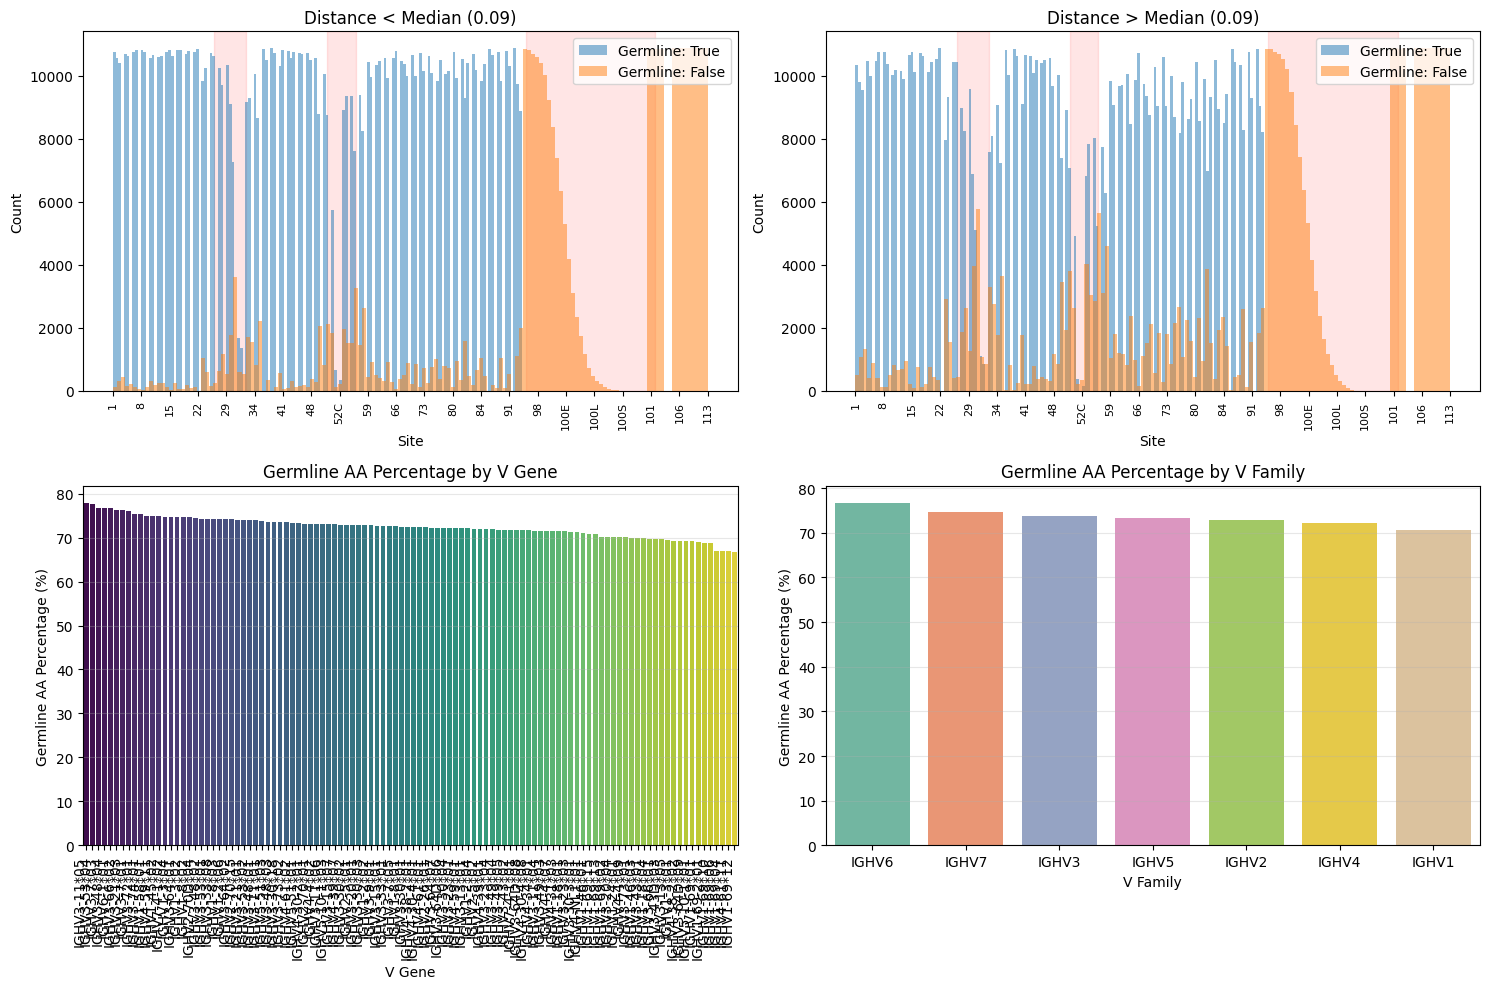

In [3]:

def create_germline_analysis_plots(site_sub_probs_df, numbering_scheme='imgt', figsize=(15, 10)):
    """
    Create comprehensive germline analysis plots:
    - Top row: Histograms by distance (< and > median)
    - Bottom row: Bar plot of germline percentage per V gene
    
    Parameters:
    -----------
    site_sub_probs_df : pd.DataFrame
        DataFrame containing site probability data with columns including:
        - site, distance, is_germline_aa, v_gene, v_family (optional)
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    figsize : tuple
        Figure size as (width, height)
    
    Returns:
    --------
    fig, axes, vgene_germline_stats
    """
    
    # Ensure site is string type
    site_sub_probs_df = site_sub_probs_df.copy()
    site_sub_probs_df['site'] = site_sub_probs_df['site'].astype(str)
    
    # Get sorted sites for consistent x-axis
    all_sites = site_sub_probs_df['site'].unique()
    sorted_sites = sort_antibody_sites(all_sites)
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    # Create 2x2 subplot layout
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    # Calculate median distance
    median_distance = site_sub_probs_df.distance.median()
    
    # === TOP ROW: Distance-based histograms ===
    
    # Histogram 1: Distance < Median
    df_low_dist = site_sub_probs_df[site_sub_probs_df.distance < median_distance].copy()
    add_cdr_shading(axes[0], sorted_sites, numbering_scheme=numbering_scheme)
    
    for is_germline in df_low_dist['is_germline_aa'].unique():
        subset = df_low_dist[df_low_dist['is_germline_aa'] == is_germline]
        x_positions = [site_to_position[site] for site in subset['site']]
        axes[0].hist(x_positions, bins=len(sorted_sites), alpha=0.5, 
                     label=f'Germline: {is_germline}')
    
    axes[0].set_title(f'Distance < Median ({median_distance:.2f})')
    axes[0].set_xlabel('Site')
    axes[0].set_ylabel('Count')
    axes[0].legend()
    axes[0].set_xticks(range(0, len(sorted_sites), max(1, len(sorted_sites)//20)))
    axes[0].set_xticklabels([sorted_sites[i] for i in range(0, len(sorted_sites), max(1, len(sorted_sites)//20))], 
                            rotation=90, fontsize=8)
    
    # Histogram 2: Distance > Median
    df_high_dist = site_sub_probs_df[site_sub_probs_df.distance > median_distance].copy()
    add_cdr_shading(axes[1], sorted_sites, numbering_scheme=numbering_scheme)
    
    for is_germline in df_high_dist['is_germline_aa'].unique():
        subset = df_high_dist[df_high_dist['is_germline_aa'] == is_germline]
        x_positions = [site_to_position[site] for site in subset['site']]
        axes[1].hist(x_positions, bins=len(sorted_sites), alpha=0.5, 
                     label=f'Germline: {is_germline}')
    
    axes[1].set_title(f'Distance > Median ({median_distance:.2f})')
    axes[1].set_xlabel('Site')
    axes[1].set_ylabel('Count')
    axes[1].legend()
    axes[1].set_xticks(range(0, len(sorted_sites), max(1, len(sorted_sites)//20)))
    axes[1].set_xticklabels([sorted_sites[i] for i in range(0, len(sorted_sites), max(1, len(sorted_sites)//20))], 
                            rotation=90, fontsize=8)
    
    # === BOTTOM ROW: V gene/family germline percentage analysis ===
    
    # Calculate germline percentage per V gene
    vgene_germline_stats = site_sub_probs_df.groupby('v_gene').agg({
        'is_germline_aa': ['count', 'sum']
    }).reset_index()
    
    # Flatten column names
    vgene_germline_stats.columns = ['v_gene', 'total_count', 'germline_count']
    vgene_germline_stats['germline_percentage'] = (vgene_germline_stats['germline_count'] / 
                                                   vgene_germline_stats['total_count']) * 100
    
    # Sort by germline percentage for better visualization
    vgene_germline_stats = vgene_germline_stats.sort_values('germline_percentage', ascending=False)
    
    # Create bar plot
    sns.barplot(data=vgene_germline_stats, x='v_gene', y='germline_percentage', 
                ax=axes[2], palette='viridis')
    axes[2].set_title('Germline AA Percentage by V Gene')
    axes[2].set_ylabel('Germline AA Percentage (%)')
    axes[2].set_xlabel('V Gene')
    plt.setp(axes[2].get_xticklabels(), rotation=90, ha='right')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    # Fourth subplot: V family level analysis
    if 'v_family' in site_sub_probs_df.columns:
        vfamily_germline_stats = site_sub_probs_df.groupby('v_family').agg({
            'is_germline_aa': ['count', 'sum']
        }).reset_index()
        
        vfamily_germline_stats.columns = ['v_family', 'total_count', 'germline_count']
        vfamily_germline_stats['germline_percentage'] = (vfamily_germline_stats['germline_count'] / 
                                                         vfamily_germline_stats['total_count']) * 100
        
        # Sort by germline percentage
        vfamily_germline_stats = vfamily_germline_stats.sort_values('germline_percentage', ascending=False)
        
        sns.barplot(data=vfamily_germline_stats, x='v_family', y='germline_percentage', 
                    ax=axes[3], palette='Set2')
        axes[3].set_title('Germline AA Percentage by V Family')
        axes[3].set_ylabel('Germline AA Percentage (%)')
        axes[3].set_xlabel('V Family')
        axes[3].grid(True, alpha=0.3, axis='y')
    else:
        # If no v_family column, create a summary statistics plot
        axes[3].text(0.5, 0.5, 'V Family data\nnot available', 
                     transform=axes[3].transAxes, ha='center', va='center', fontsize=12)
        axes[3].set_title('V Family Analysis')
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes, vgene_germline_stats

# Comprehensive analysis
fig, axes, stats = create_germline_analysis_plots(site_sub_probs_df, numbering_scheme=numbering_scheme)

## Analysis

In [4]:
site_sub_probs_df

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,family,depth,distance,v_gene,j_gene_y,v_family,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon
0,0.102066,0.132334,0.013507,False,0,1,False,CAG,Q,CAG,...,1401,2,0.096444,IGHV7-4-1*02,IGHJ4*02,IGHV7,CAG,Q,True,True
1,0.030019,0.132334,0.003972,False,1,1,False,CAG,Q,CAG,...,1401,2,0.031971,IGHV7-4-1*02,IGHJ4*02,IGHV7,CAG,Q,True,True
2,0.011072,0.229902,0.002546,False,2,1,False,CAG,Q,CAG,...,474,2,0.079722,IGHV4-59*01,IGHJ4*02,IGHV4,CAG,Q,True,True
3,0.054606,0.262477,0.014333,False,3,1,False,CAG,Q,CAG,...,238,2,0.094379,IGHV4-31*03,IGHJ6*02,IGHV4,CAG,Q,True,True
4,0.010781,0.262477,0.002830,False,4,1,False,CAG,Q,CAG,...,238,2,0.069703,IGHV4-31*03,IGHJ6*02,IGHV4,CAG,Q,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2647825,0.001440,1.122413,0.001617,False,21747,113,False,TCA,S,TCA,...,62,2,0.039758,IGHV1-8*02,IGHJ1*01,IGHV1,NaN,NaN,False,False
2647826,0.001785,1.077277,0.001923,False,21748,113,False,TCA,S,TCA,...,10,2,0.109737,IGHV3-7*01,IGHJ5*02,IGHV3,NaN,NaN,False,False
2647827,0.001744,1.077277,0.001879,False,21749,113,False,TCA,S,TCA,...,10,3,0.112585,IGHV3-7*01,IGHJ5*02,IGHV3,NaN,NaN,False,False
2647828,0.001797,1.249783,0.002246,False,21750,113,False,TCA,S,TCA,...,10,2,0.119753,IGHV1-18*01,IGHJ4*02,IGHV1,NaN,NaN,False,False


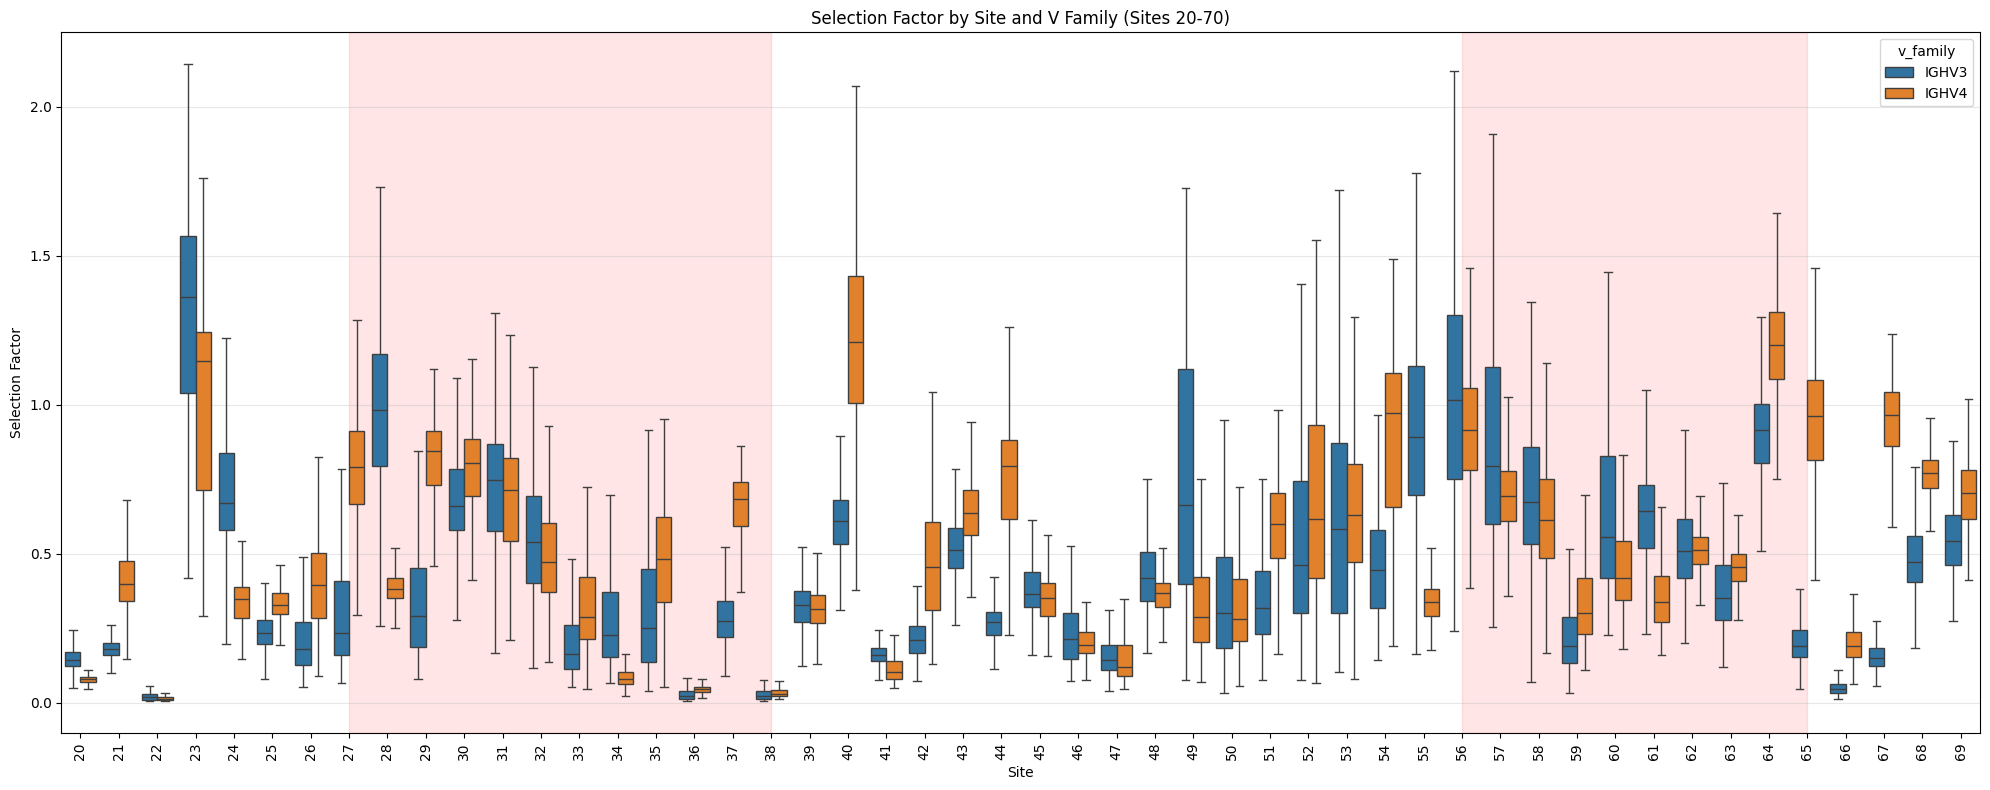

In [ ]:
# Filter data
filtered_df = site_sub_probs_df[
    (site_sub_probs_df.v_family.isin(['IGHV3', 'IGHV4']))
].copy()

# Get sites in range 20-70 (as strings)
site_range = [str(i) for i in range(20, 70)]
filtered_df = filtered_df[filtered_df['site'].isin(site_range)]

# Sort sites properly
sorted_sites = sort_antibody_sites(filtered_df['site'].unique())
site_to_position = {site: i for i, site in enumerate(sorted_sites)}

# Create figure
fig, ax = plt.subplots(figsize=(20, 8))

# Add CDR shading
add_cdr_shading(ax, sorted_sites, numbering_scheme='imgt')

# Create boxplot with proper ordering
# Map sites to their positions for plotting
filtered_df['site_position'] = filtered_df['site'].map(site_to_position)
filtered_df_sorted = filtered_df.sort_values('site_position')

# Create boxplot
sns.boxplot(data=filtered_df_sorted, x='site_position', y='selection_factor', 
            hue='v_family', showfliers=False, ax=ax)

# Set x-axis labels to show actual site names
ax.set_xticks(range(len(sorted_sites)))
ax.set_xticklabels(sorted_sites, rotation=90)
ax.set_xlabel('Site')
ax.set_ylabel('Selection Factor')
ax.set_title('Selection Factor by Site and V Family (Sites 20-70)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## compare V and J gene families selection factors

In [8]:
#### per site difference between v3 and v4 usign seqeunces
## simplify DNSM paper and look at two genes



our_common_vgenes = ['IGHV3-23*01', 
                     'IGHV4-39*01']

#if wanting to compare within v family:
our_common_v3_genes = ['IGHV3-23*01', 
                     'IGHV3-74*01']

site_sub_probs_df[site_sub_probs_df.v_family.isin(['IGHV3', 'IGHV4'])].groupby('v_gene').size().sort_values(ascending=False).head(20)


v_gene
IGHV3-23*01      231781
IGHV3-74*01      129576
IGHV4-39*01      129446
IGHV3-7*01       108983
IGHV4-59*01       99520
IGHV4-34*01       83268
IGHV3-7*03        78553
IGHV3-33*01       77076
IGHV3-21*01       60678
IGHV3-15*01       56547
IGHV3-9*01        54213
IGHV4-31*03       51532
IGHV4-4*02        49604
IGHV4-39*07       47878
IGHV3-53*01       46624
IGHV4-38-2*01     39564
IGHV3-30*18       38058
IGHV3-48*03       34421
IGHV3-48*02       31900
IGHV4-61*02       27477
dtype: int64

In [9]:
def compare_v_genes_barplot(v_gene1, v_gene2, site_sub_probs_df_germline, 
                           numbering_scheme='imgt', figsize=(13, 5), limit_pcp_depth=True):
    """
    Compare two V genes with a barplot showing log selection factor differences.
    
    Parameters:
    -----------
    v_gene1, v_gene2 : str
        V gene names to compare
    site_sub_probs_df_germline : pd.DataFrame
        DataFrame with site probabilities and germline information
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    figsize : tuple
        Figure size
    limit_pcp_depth : bool
        If True, limit to depth==2 sequences
    
    Returns:
    --------
    median_log_selection_factors_compare, fig, ax
    """
    df = site_sub_probs_df_germline[site_sub_probs_df_germline.v_gene.isin([v_gene1, v_gene2])].copy()
    df = df[df['is_germline_codon'] == True]
    
    # Ensure site is string type
    df['site'] = df['site'].astype(str)

    if limit_pcp_depth:
        df = df[df.depth == 2]

    median_log_selection_factors_1 = df[(df.v_gene == v_gene1)].groupby(['site', 'parent_aa', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_2 = df[(df.v_gene == v_gene2)].groupby(['site', 'parent_aa', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    
    # Ensure site is string in both dataframes
    median_log_selection_factors_1['site'] = median_log_selection_factors_1['site'].astype(str)
    median_log_selection_factors_2['site'] = median_log_selection_factors_2['site'].astype(str)
    
    median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, 
                                                     on=['site', 'is_cdr'], how='inner', suffixes=('_1', '_2'))
    
    # Calculate difference (v_gene1 - v_gene2)
    median_log_selection_factors_compare['difference'] = (median_log_selection_factors_compare['log_selection_factor_1'] - 
                                                         median_log_selection_factors_compare['log_selection_factor_2'])
    
    # Add color column to dataframe based on whether parent amino acids are different
    median_log_selection_factors_compare['germline_aa_status'] = median_log_selection_factors_compare.apply(
        lambda row: 'Different germline AA' if row['parent_aa_1'] != row['parent_aa_2'] else 'Same germline AA', axis=1
    )

    # Sort sites properly
    sorted_sites = sort_antibody_sites(median_log_selection_factors_compare['site'].unique())
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    # Add position column for plotting
    median_log_selection_factors_compare['site_position'] = median_log_selection_factors_compare['site'].map(site_to_position)
    median_log_selection_factors_compare_sorted = median_log_selection_factors_compare.sort_values('site_position')
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Add CDR shading
    add_cdr_shading(ax, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Create barplot - separate by germline_aa_status
    for status in ['Same germline AA', 'Different germline AA']:
        subset = median_log_selection_factors_compare_sorted[
            median_log_selection_factors_compare_sorted['germline_aa_status'] == status
        ]
        color = 'blue' if status == 'Same germline AA' else 'red'
        ax.bar(subset['site_position'], subset['difference'], 
               color=color, alpha=0.7, label=status, width=0.8)
    
    # Customize the plot
    ax.set_xlabel('Site', fontsize=12)
    ax.set_ylabel(f'Log Selection Factor Difference\n({v_gene1} - {v_gene2})', fontsize=12)
    ax.set_title(f'Selection Factor Differences: {v_gene1} vs {v_gene2}', fontsize=14)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set x-axis ticks and labels
    ax.set_xticks(range(len(sorted_sites)))
    ax.set_xticklabels(sorted_sites, rotation=90)
    
    # Create custom legend
    legend_elements = [
        Patch(facecolor='blue', alpha=0.7, label='Same germline AA'),
        Patch(facecolor='red', alpha=0.7, label='Different germline AA')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return median_log_selection_factors_compare, fig, ax


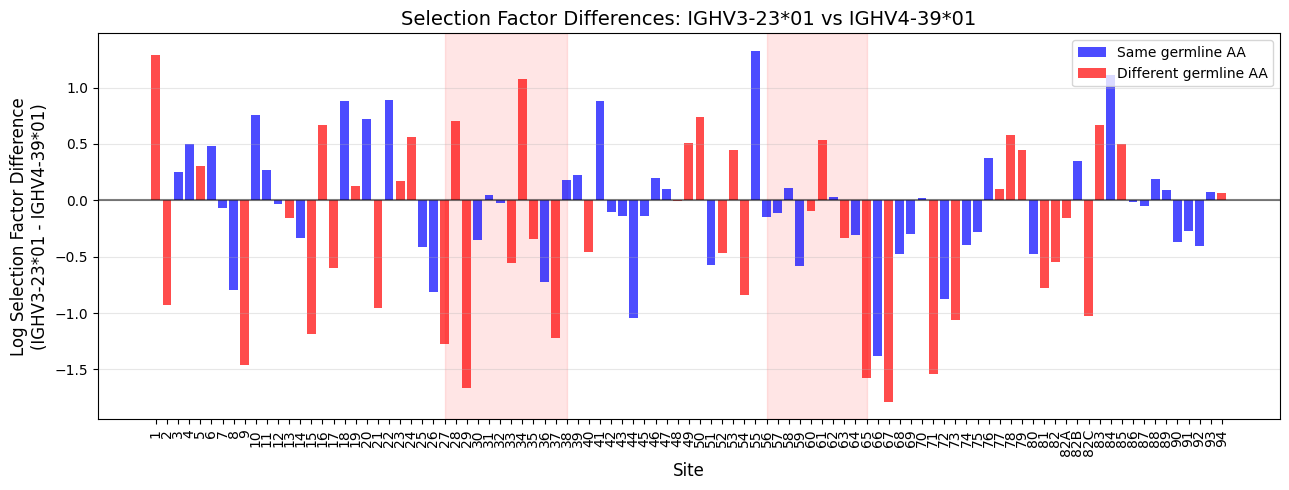

,site,parent_aa_1,is_cdr,log_selection_factor_1,parent_aa_2,log_selection_factor_2,difference,germline_aa_status,site_position
0,1,E,False,-0.640403,Q,-1.928715,1.288311,Different germline AA,0
1,10,G,False,-0.164597,G,-0.924547,0.759949,Same germline AA,9
2,11,L,False,-0.673771,L,-0.945208,0.271437,Same germline AA,10
3,12,V,False,-1.023418,V,-0.991040,-0.032377,Same germline AA,11
4,13,Q,False,-0.923386,K,-0.765103,-0.158283,Different germline AA,12
...,...,...,...,...,...,...,...,...,...
92,90,Y,False,-3.077725,Y,-2.704703,-0.373022,Same germline AA,92
93,91,Y,False,-0.963619,Y,-0.692952,-0.270667,Same germline AA,93
94,92,C,False,-3.085731,C,-2.683124,-0.402607,Same germline AA,94
95,93,A,True,-0.343721,A,-0.417266,0.073545,Same germline AA,95


In [ ]:

median_log_selection_factors_compare, fig, ax = compare_v_genes_barplot('IGHV3-23*01', 'IGHV4-39*01', site_sub_probs_df)
median_log_selection_factors_compare

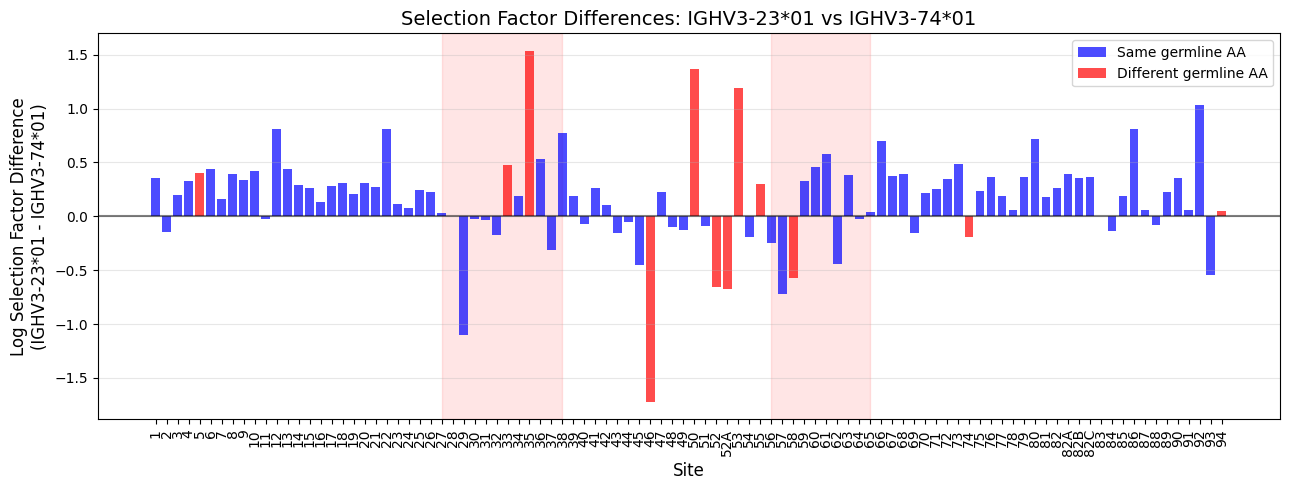

In [12]:
### THIS PLOT SHOWS THAT COMPARING ONLY TWO GENES MIGHT BE MISLEADING, AS23*01 HAS MORE SELECTION THAT 74*01 ACROSS MOST SITES, WHICH LOOKS LIKE AN ARTIFACT.

median_log_selection_factors_compare, fig, ax = compare_v_genes_barplot('IGHV3-23*01', 'IGHV3-74*01', site_sub_probs_df)

/tmp/ipykernel_1250371/3542807436.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


[Text(0, 0, '1'),
 Text(1, 0, '2'),
 Text(2, 0, '3'),
 Text(3, 0, '4'),
 Text(4, 0, '5'),
 Text(5, 0, '6'),
 Text(6, 0, '7'),
 Text(7, 0, '8'),
 Text(8, 0, '9'),
 Text(9, 0, '10'),
 Text(10, 0, '11'),
 Text(11, 0, '12'),
 Text(12, 0, '13'),
 Text(13, 0, '14'),
 Text(14, 0, '15'),
 Text(15, 0, '16'),
 Text(16, 0, '17'),
 Text(17, 0, '18'),
 Text(18, 0, '19'),
 Text(19, 0, '20'),
 Text(20, 0, '21'),
 Text(21, 0, '22'),
 Text(22, 0, '23'),
 Text(23, 0, '24'),
 Text(24, 0, '25'),
 Text(25, 0, '26'),
 Text(26, 0, '27'),
 Text(27, 0, '28'),
 Text(28, 0, '29'),
 Text(29, 0, '30'),
 Text(30, 0, '31'),
 Text(31, 0, '32'),
 Text(32, 0, '33'),
 Text(33, 0, '34'),
 Text(34, 0, '35'),
 Text(35, 0, '36'),
 Text(36, 0, '37'),
 Text(37, 0, '38'),
 Text(38, 0, '39'),
 Text(39, 0, '40'),
 Text(40, 0, '41'),
 Text(41, 0, '42'),
 Text(42, 0, '43'),
 Text(43, 0, '44'),
 Text(44, 0, '45'),
 Text(45, 0, '46'),
 Text(46, 0, '47'),
 Text(47, 0, '48'),
 Text(48, 0, '49'),
 Text(49, 0, '50'),
 Text(50, 0, '51'),

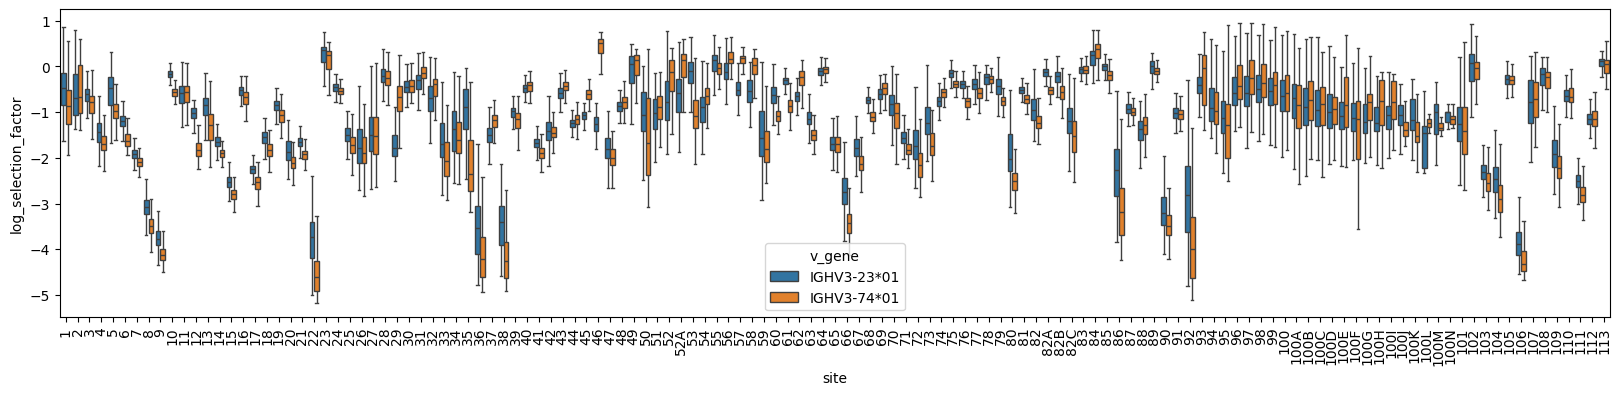

In [13]:
fig, ax = plt.subplots(figsize=(20, 4))
sns.boxplot(site_sub_probs_df[site_sub_probs_df.v_gene.isin(['IGHV3-23*01', 'IGHV3-74*01'])], x='site', y='log_selection_factor', hue='v_gene', showfliers=False)
# rotate x ticks labels 90
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


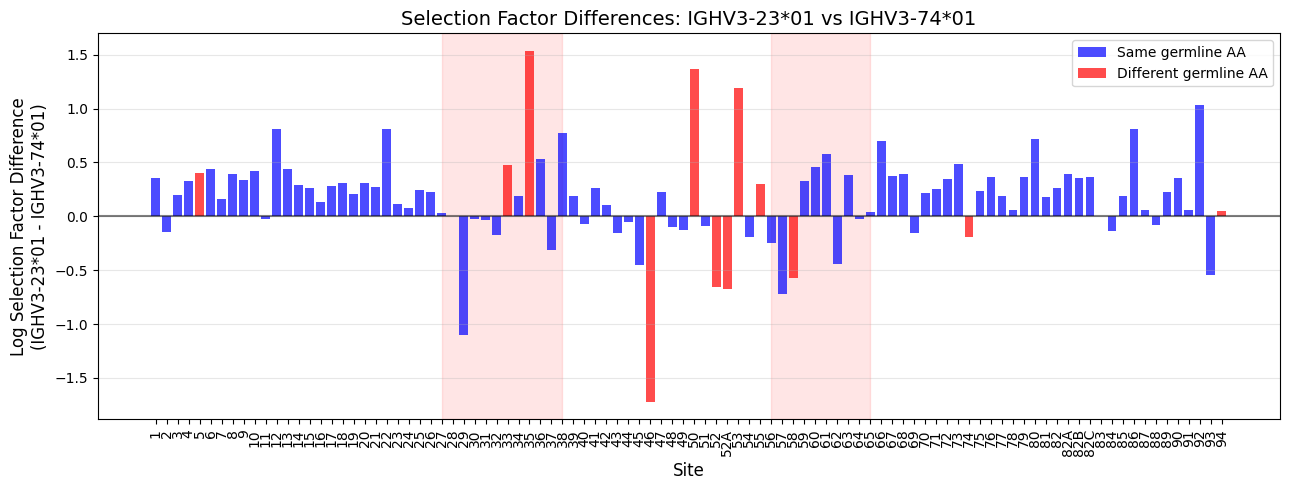

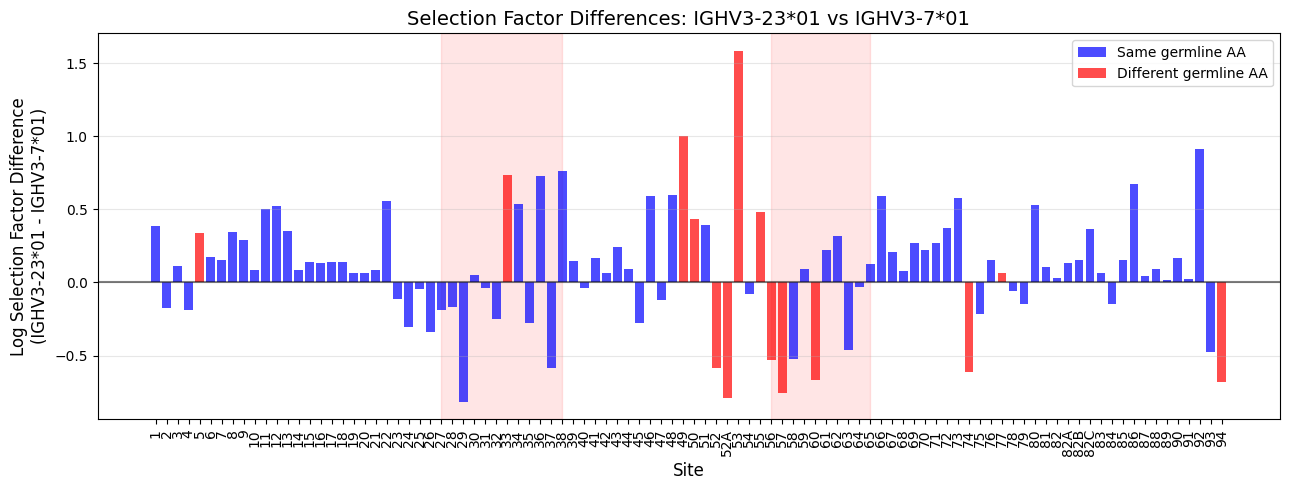

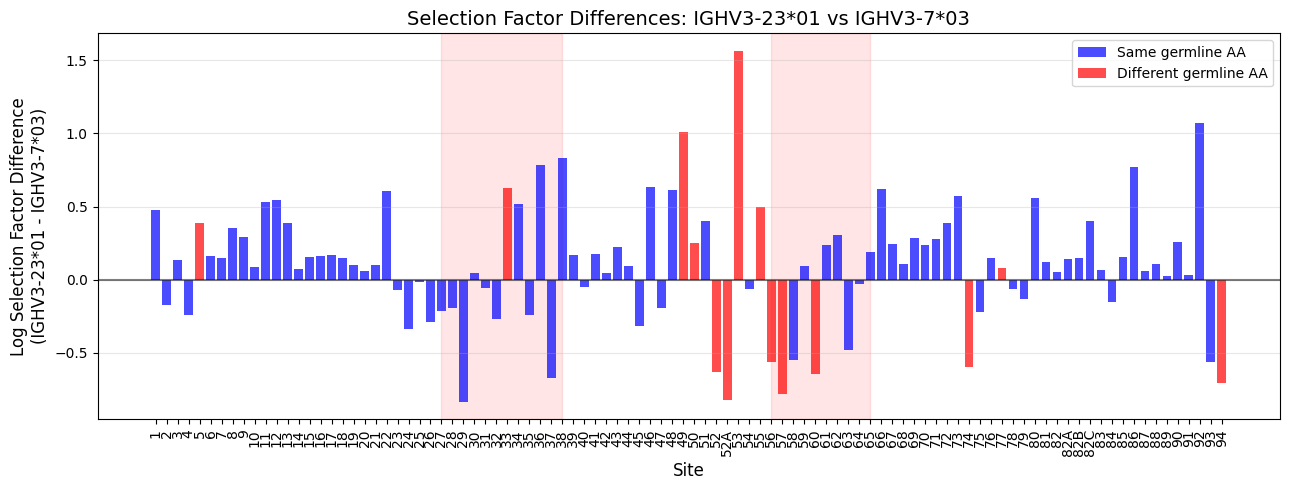

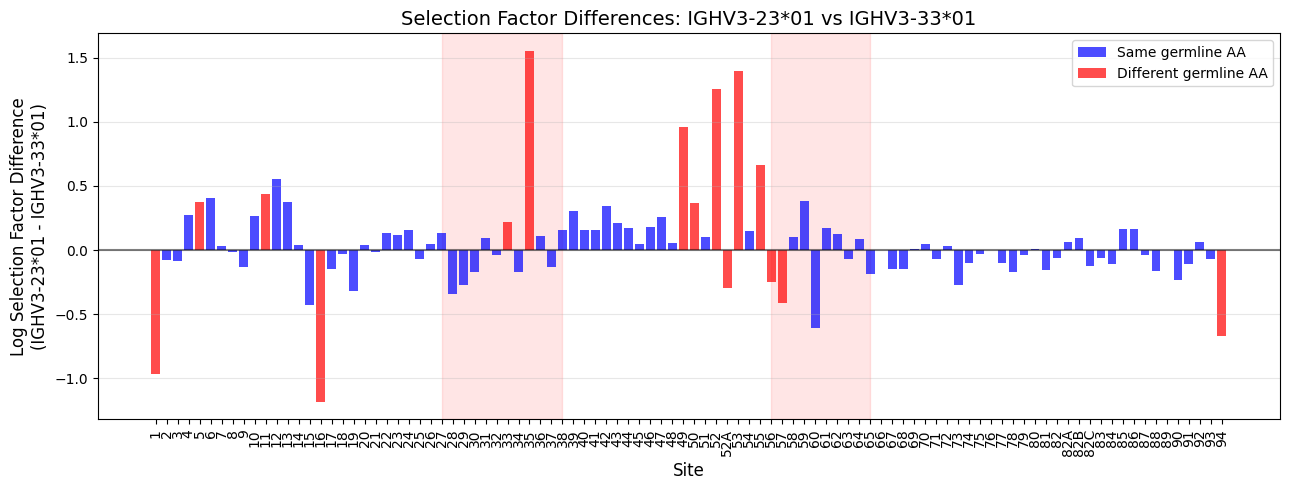

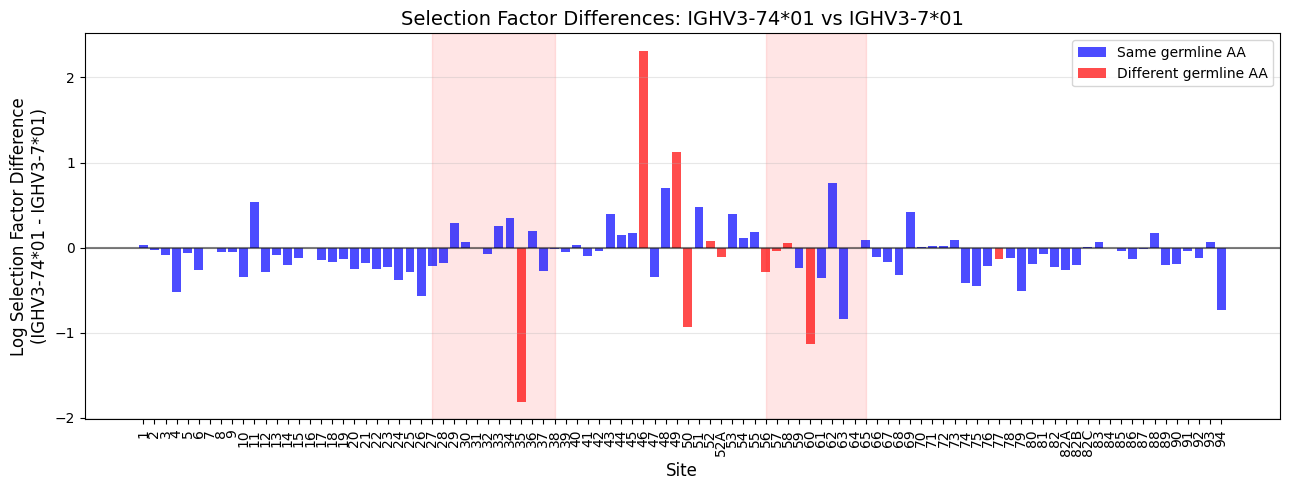

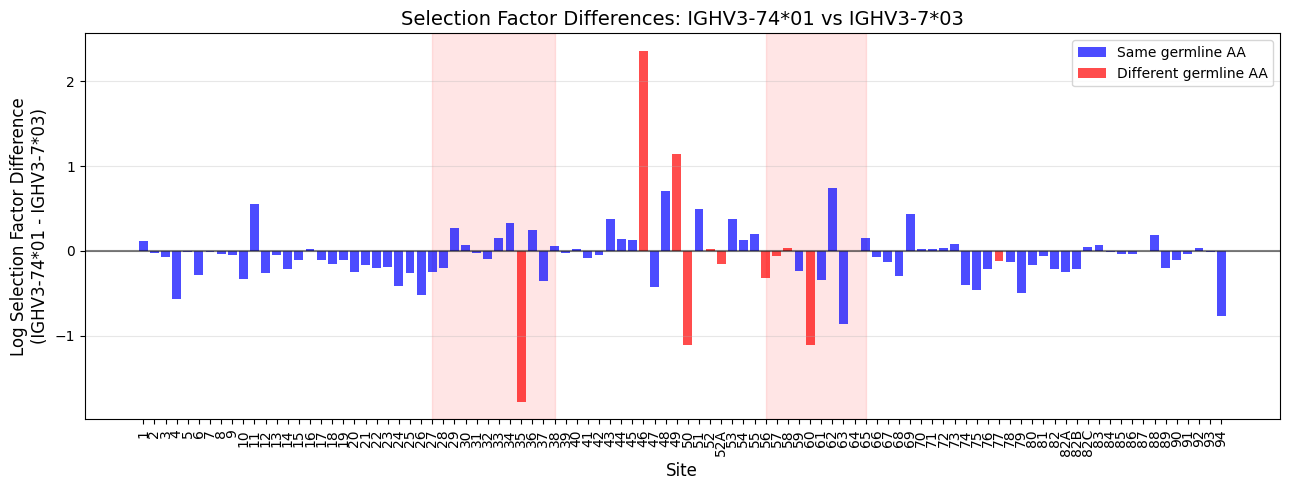

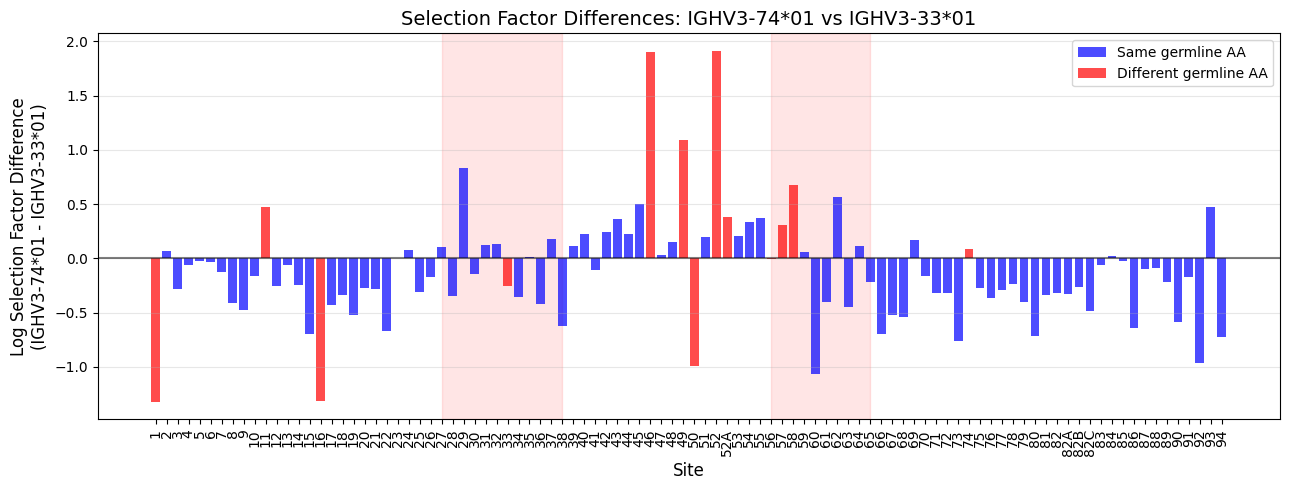

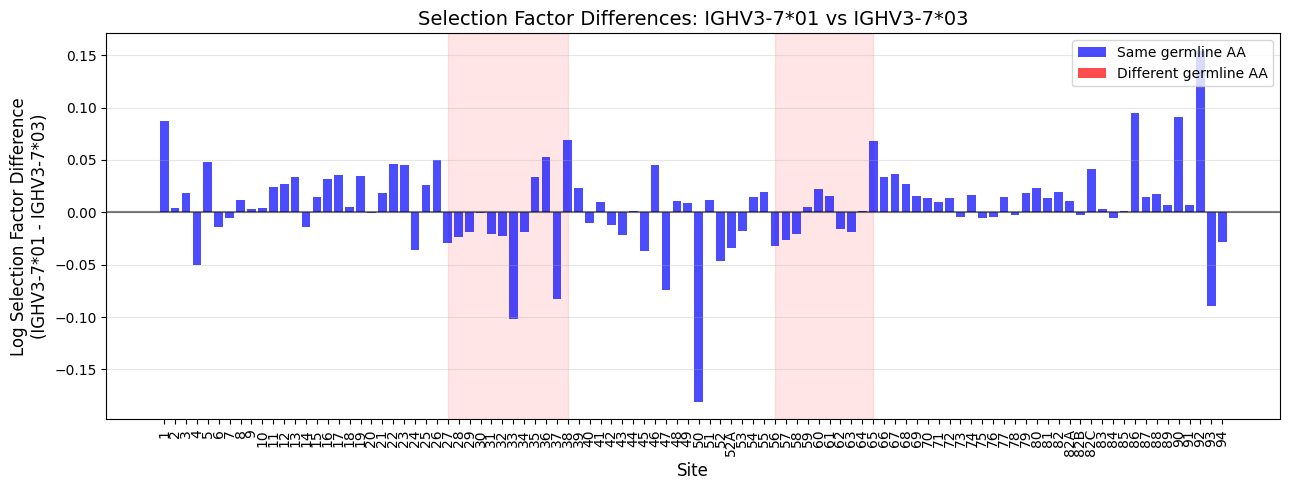

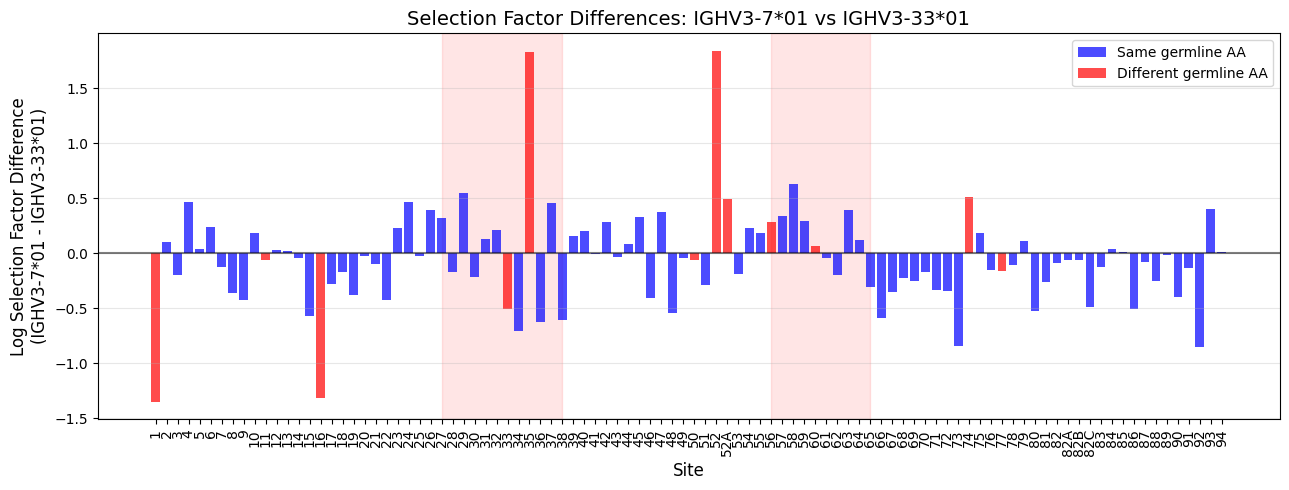

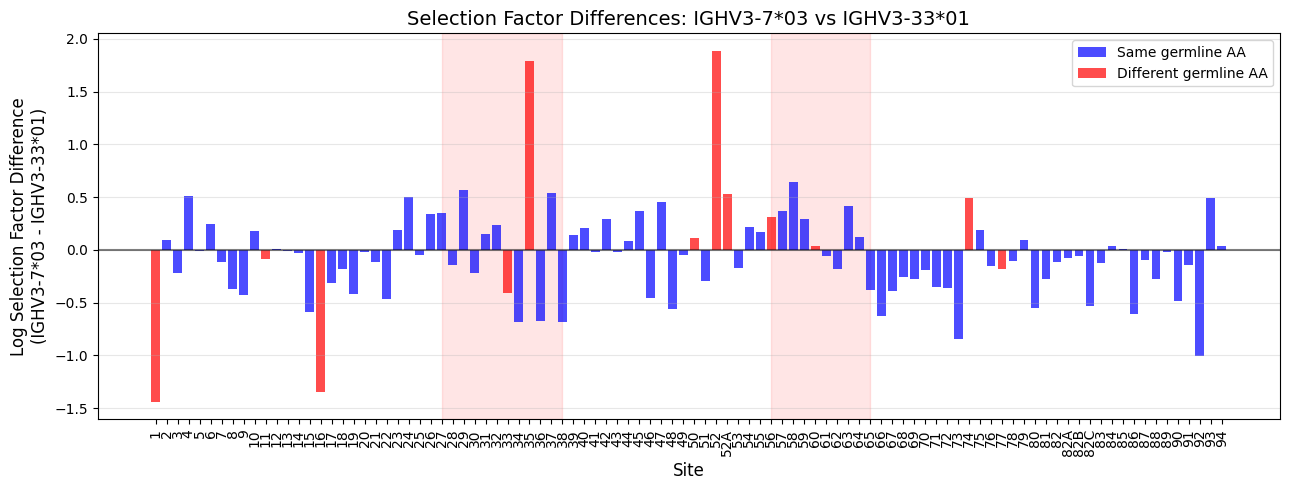

In [14]:
## let's take a look at more v genes and see if this recurs

v_genes_to_test = site_sub_probs_df[site_sub_probs_df.v_family.isin(['IGHV3'])].groupby('v_gene').size().sort_values(ascending=False).head(5).reset_index().v_gene.tolist()
# get all combinations of v_genes_to_test, order doesn't matter
v_genes_to_test = list(combinations(v_genes_to_test, 2))
for v_gene1, v_gene2 in v_genes_to_test:
    if v_gene1 != v_gene2:
        median_log_selection_factors_compare, fig, ax = compare_v_genes_barplot(v_gene1, v_gene2, site_sub_probs_df)
        plt.show()


# Look at DNSM factors together with germline identities. 
There are two versions below - one with the amino acid distribution according to all the possible germline genes, and the other according to the distribution of the germline encoded sites in the Rodriguez dataset. They are pretty similar.

/tmp/ipykernel_1250371/3589558316.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


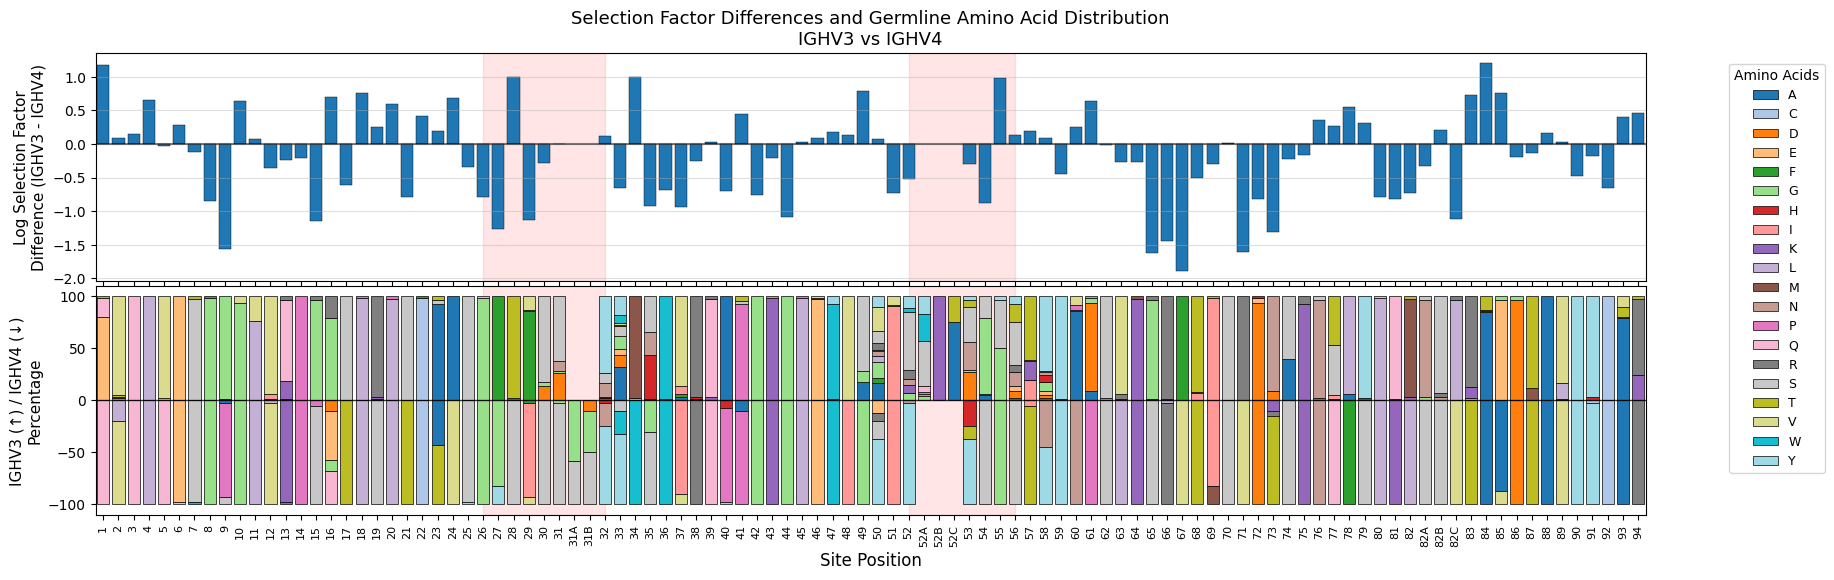

In [25]:
def combined_vfamily_plots(v_family1, v_family2, germline_codons_df, site_sub_probs_df_germline, 
                          numbering_scheme='imgt', figsize=(20, 6)):
    """
    Create combined plots:
    - Top: Selection factor differences (bar plot with CDR shading)
    - Bottom: Mirrored amino acid distribution 
    Both plots share the same x-axis
    
    Parameters:
    -----------
    v_family1, v_family2 : str
        V family names to compare
    germline_codons_df : pd.DataFrame
        Germline codon data
    site_sub_probs_df_germline : pd.DataFrame
        Site probabilities with germline information
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    figsize : tuple
        Figure size
    
    Returns:
    --------
    median_log_selection_factors_compare, fig, (ax1, ax2)
    """
    
    # Ensure site columns are strings
    germline_codons_df = germline_codons_df.copy()
    germline_codons_df['site'] = germline_codons_df['site'].astype(str)
    
    # Create subplots with shared x-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.02})
    
    # ===== TOP PLOT: SELECTION FACTOR DIFFERENCES =====
    
    # Prepare selection factor data (without is_cdr grouping)
    df = site_sub_probs_df_germline[site_sub_probs_df_germline.v_family.isin([v_family1, v_family2])].copy()
    df = df[df['is_germline_codon'] == True]
    df['site'] = df['site'].astype(str)

    # Group by site only (not by is_cdr)
    median_log_selection_factors_1 = df[(df.v_family == v_family1)].groupby('site').log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_2 = df[(df.v_family == v_family2)].groupby('site').log_selection_factor.median().reset_index().copy()
    
    # Ensure site is string
    median_log_selection_factors_1['site'] = median_log_selection_factors_1['site'].astype(str)
    median_log_selection_factors_2['site'] = median_log_selection_factors_2['site'].astype(str)
    
    # Merge without is_cdr
    median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, 
                                                     on='site', how='inner', suffixes=('_1', '_2'))
    
    # Calculate difference
    median_log_selection_factors_compare['difference'] = (median_log_selection_factors_compare['log_selection_factor_1'] - 
                                                         median_log_selection_factors_compare['log_selection_factor_2'])
    
    # Get germline data for amino acid distribution
    family1_data = germline_codons_df[germline_codons_df.v_family == v_family1].copy()
    family2_data = germline_codons_df[germline_codons_df.v_family == v_family2].copy()
    
    # Get all sites and sort them properly
    all_sites_with_data = sorted(set(family1_data['site'].unique()) | set(family2_data['site'].unique()))
    sorted_sites = sort_antibody_sites(all_sites_with_data)
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    if len(sorted_sites) == 0:
        print("Warning: No data found for one or both V families")
        return None, None, None
    
    # Add CDR shading to both plots
    add_cdr_shading(ax1, sorted_sites, numbering_scheme=numbering_scheme)
    add_cdr_shading(ax2, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Plot selection factor differences
    # Map sites to positions
    median_log_selection_factors_compare['site_position'] = median_log_selection_factors_compare['site'].map(site_to_position)
    
    # Use single color for all bars
    ax1.bar(median_log_selection_factors_compare['site_position'], 
            median_log_selection_factors_compare['difference'], 
            color='#1f77b4', width=0.8, edgecolor='black', linewidth=0.3)
    
    # Customize top plot
    ax1.set_ylabel(f'Log Selection Factor\nDifference ({v_family1} - {v_family2})', fontsize=11)
    ax1.set_title(f'Selection Factor Differences and Germline Amino Acid Distribution\n{v_family1} vs {v_family2}', fontsize=13)
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax1.grid(True, alpha=0.4, linewidth=0.8, axis='y')
    
    # ===== BOTTOM PLOT: MIRRORED AMINO ACID DISTRIBUTION =====
    
    # Get all unique amino acids
    all_amino_acids = sorted(set(family1_data['amino_acid'].unique()) | 
                           set(family2_data['amino_acid'].unique()))
    
    # Use tab20 colormap
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_amino_acids)))
    color_map = dict(zip(all_amino_acids, colors))
    
    # Calculate percentages for family1 at specific sites
    family1_site_counts = {}
    for aa in all_amino_acids:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family1_site_counts[aa] = site_counts
    
    # Calculate percentages for family2 at specific sites  
    family2_site_counts = {}
    for aa in all_amino_acids:
        aa_data = family2_data[family2_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family2_site_counts[aa] = site_counts
    
    # Plot family1 above x-axis (positive values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom1 = 0
        site_total = sum([family1_site_counts[aa].get(site, 0) for aa in all_amino_acids])
        
        for aa in all_amino_acids:
            count = family1_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = (count / site_total) * 100
                ax2.bar(site_pos, percentage, bottom=bottom1, 
                       color=color_map[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom1 += percentage
    
    # Plot family2 below x-axis (negative values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom2 = 0
        site_total = sum([family2_site_counts[aa].get(site, 0) for aa in all_amino_acids])
        
        for aa in all_amino_acids:
            count = family2_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = -(count / site_total) * 100  # Negative for below x-axis
                ax2.bar(site_pos, percentage, bottom=bottom2, 
                       color=color_map[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom2 += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'{v_family1} (↑) / {v_family2} (↓)\nPercentage', fontsize=11)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in all_amino_acids:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_map[aa], 
                                          edgecolor='black', linewidth=0.5))
        legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, bbox_to_anchor=(1.05, 2), loc='upper left', 
              title='Amino Acids', fontsize=9)
    
    # Set x-axis for both plots
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax2.set_xlim(-0.5, len(sorted_sites) - 0.5)
    
    # Set x-axis ticks
    ax1.set_xticks(range(len(sorted_sites)))
    ax2.set_xticks(range(len(sorted_sites)))
    
    # Only show x-tick labels on bottom plot
    ax1.set_xticklabels([])
    ax2.set_xlabel('Site Position', fontsize=12)
    ax2.set_xticklabels(sorted_sites, rotation=90, fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    return median_log_selection_factors_compare, fig, (ax1, ax2)

# Usage:
result_df, fig, (ax1, ax2) = combined_vfamily_plots('IGHV3', 'IGHV4', germline_codons_df, site_sub_probs_df, 
                                                     numbering_scheme=numbering_scheme)


/tmp/ipykernel_1250371/604753677.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


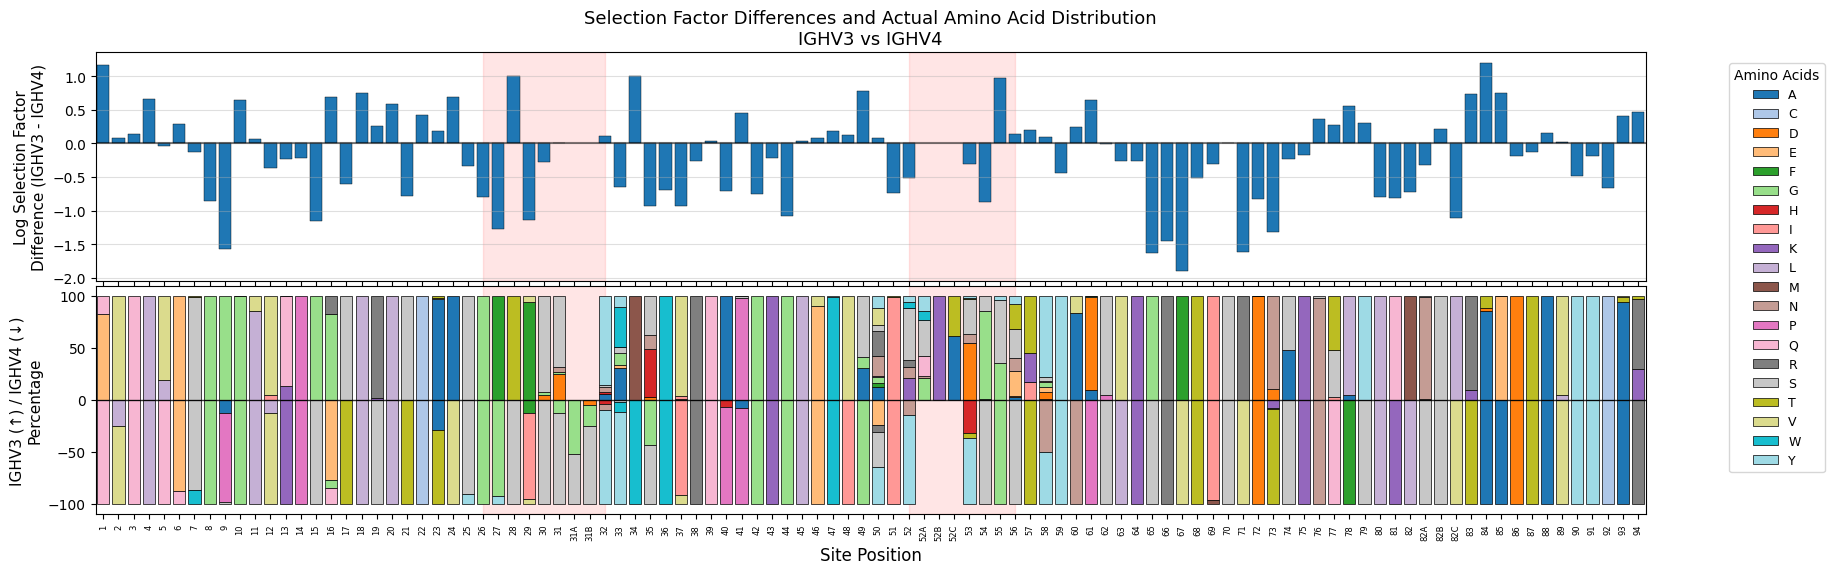

In [26]:
def combined_vfamily_plots_actual_aa(v_family1, v_family2, site_sub_probs_df_germline, 
                                    numbering_scheme='imgt', figsize=(20, 6)):
    """
    Create combined plots:
    - Top: Selection factor differences (bar plot)
    - Bottom: Mirrored amino acid distribution from actual data (parent_aa column)
    Both plots share the same x-axis
    
    Parameters:
    -----------
    v_family1, v_family2 : str
        V family names to compare
    site_sub_probs_df_germline : pd.DataFrame
        Site probabilities with germline information including parent_aa column
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    figsize : tuple
        Figure size
    
    Returns:
    --------
    median_log_selection_factors_compare, fig, (ax1, ax2)
    """
    from utils import sort_antibody_sites, add_cdr_shading
    
    # Ensure site column is string
    site_sub_probs_df_germline = site_sub_probs_df_germline.copy()
    site_sub_probs_df_germline['site'] = site_sub_probs_df_germline['site'].astype(str)
    
    # Create subplots with shared x-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.02})
    
    # ===== TOP PLOT: SELECTION FACTOR DIFFERENCES =====
    
    # Prepare selection factor data (without is_cdr grouping)
    df = site_sub_probs_df_germline[site_sub_probs_df_germline.v_family.isin([v_family1, v_family2])].copy()
    df = df[df['is_germline_codon'] == True]
    df['site'] = df['site'].astype(str)
    
    # Group by site only (not by is_cdr)
    median_log_selection_factors_1 = df[(df.v_family == v_family1)].groupby('site').log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_2 = df[(df.v_family == v_family2)].groupby('site').log_selection_factor.median().reset_index().copy()
    
    # Ensure site is string
    median_log_selection_factors_1['site'] = median_log_selection_factors_1['site'].astype(str)
    median_log_selection_factors_2['site'] = median_log_selection_factors_2['site'].astype(str)
    
    # Merge without is_cdr
    median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, 
                                                     on='site', how='inner', suffixes=('_1', '_2'))
    
    # Calculate difference
    median_log_selection_factors_compare['difference'] = (median_log_selection_factors_compare['log_selection_factor_1'] - 
                                                         median_log_selection_factors_compare['log_selection_factor_2'])
    
    # Filter data for each family
    family1_data = df[df.v_family == v_family1].copy()
    family2_data = df[df.v_family == v_family2].copy()
    
    # Get all sites and sort them properly
    all_sites_with_data = sorted(set(family1_data['site'].unique()) | set(family2_data['site'].unique()))
    sorted_sites = sort_antibody_sites(all_sites_with_data)
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    if len(sorted_sites) == 0:
        print("Warning: No data found for one or both V families")
        return None, None, None
    
    # Add CDR shading to both plots
    add_cdr_shading(ax1, sorted_sites, numbering_scheme=numbering_scheme)
    add_cdr_shading(ax2, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Plot selection factor differences
    # Map sites to positions
    median_log_selection_factors_compare['site_position'] = median_log_selection_factors_compare['site'].map(site_to_position)
    
    # Use single color for all bars
    ax1.bar(median_log_selection_factors_compare['site_position'], 
            median_log_selection_factors_compare['difference'], 
            color='#1f77b4', width=0.8, edgecolor='black', linewidth=0.3)
    
    # Customize top plot
    ax1.set_ylabel(f'Log Selection Factor\nDifference ({v_family1} - {v_family2})', fontsize=11)
    ax1.set_title(f'Selection Factor Differences and Actual Amino Acid Distribution\n{v_family1} vs {v_family2}', fontsize=13)
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax1.grid(True, alpha=0.4, linewidth=0.8, axis='y')
    
    # ===== BOTTOM PLOT: MIRRORED AMINO ACID DISTRIBUTION FROM ACTUAL DATA =====
    
    # Get all unique amino acids from both families (from parent_aa column)
    all_amino_acids = sorted(set(family1_data['parent_aa'].unique()) | 
                           set(family2_data['parent_aa'].unique()))
    
    # Use tab20 colormap
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_amino_acids)))
    color_map = dict(zip(all_amino_acids, colors))
    
    # Calculate percentages for family1 at specific sites
    family1_site_counts = {}
    for aa in all_amino_acids:
        aa_data = family1_data[family1_data['parent_aa'] == aa]
        site_counts = aa_data['site'].value_counts()
        family1_site_counts[aa] = site_counts
    
    # Calculate percentages for family2 at specific sites  
    family2_site_counts = {}
    for aa in all_amino_acids:
        aa_data = family2_data[family2_data['parent_aa'] == aa]
        site_counts = aa_data['site'].value_counts()
        family2_site_counts[aa] = site_counts
    
    # Plot family1 above x-axis (positive values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom1 = 0
        site_total = sum([family1_site_counts[aa].get(site, 0) for aa in all_amino_acids])
        
        for aa in all_amino_acids:
            count = family1_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = (count / site_total) * 100
                ax2.bar(site_pos, percentage, bottom=bottom1, 
                       color=color_map[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom1 += percentage
    
    # Plot family2 below x-axis (negative values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom2 = 0
        site_total = sum([family2_site_counts[aa].get(site, 0) for aa in all_amino_acids])
        
        for aa in all_amino_acids:
            count = family2_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = -(count / site_total) * 100  # Negative for below x-axis
                ax2.bar(site_pos, percentage, bottom=bottom2, 
                       color=color_map[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom2 += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'{v_family1} (↑) / {v_family2} (↓)\nPercentage', fontsize=11)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in all_amino_acids:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_map[aa], 
                                          edgecolor='black', linewidth=0.5))
        legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, bbox_to_anchor=(1.05, 2), loc='upper left', 
              title='Amino Acids', fontsize=9)
    
    # Set x-axis for both plots
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax2.set_xlim(-0.5, len(sorted_sites) - 0.5)
    
    # Set x-axis ticks
    ax1.set_xticks(range(len(sorted_sites)))
    ax2.set_xticks(range(len(sorted_sites)))
    
    # Only show x-tick labels on bottom plot
    ax1.set_xticklabels([])
    ax2.set_xlabel('Site Position', fontsize=12)
    ax2.set_xticklabels(sorted_sites, rotation=90, fontsize=6)
    
    plt.tight_layout()
    plt.show()
    
    return median_log_selection_factors_compare, fig, (ax1, ax2)

# Usage:
result_df, fig, (ax1, ax2) = combined_vfamily_plots_actual_aa('IGHV3', 'IGHV4', site_sub_probs_df, numbering_scheme=numbering_scheme)

/tmp/ipykernel_1250371/3520060400.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


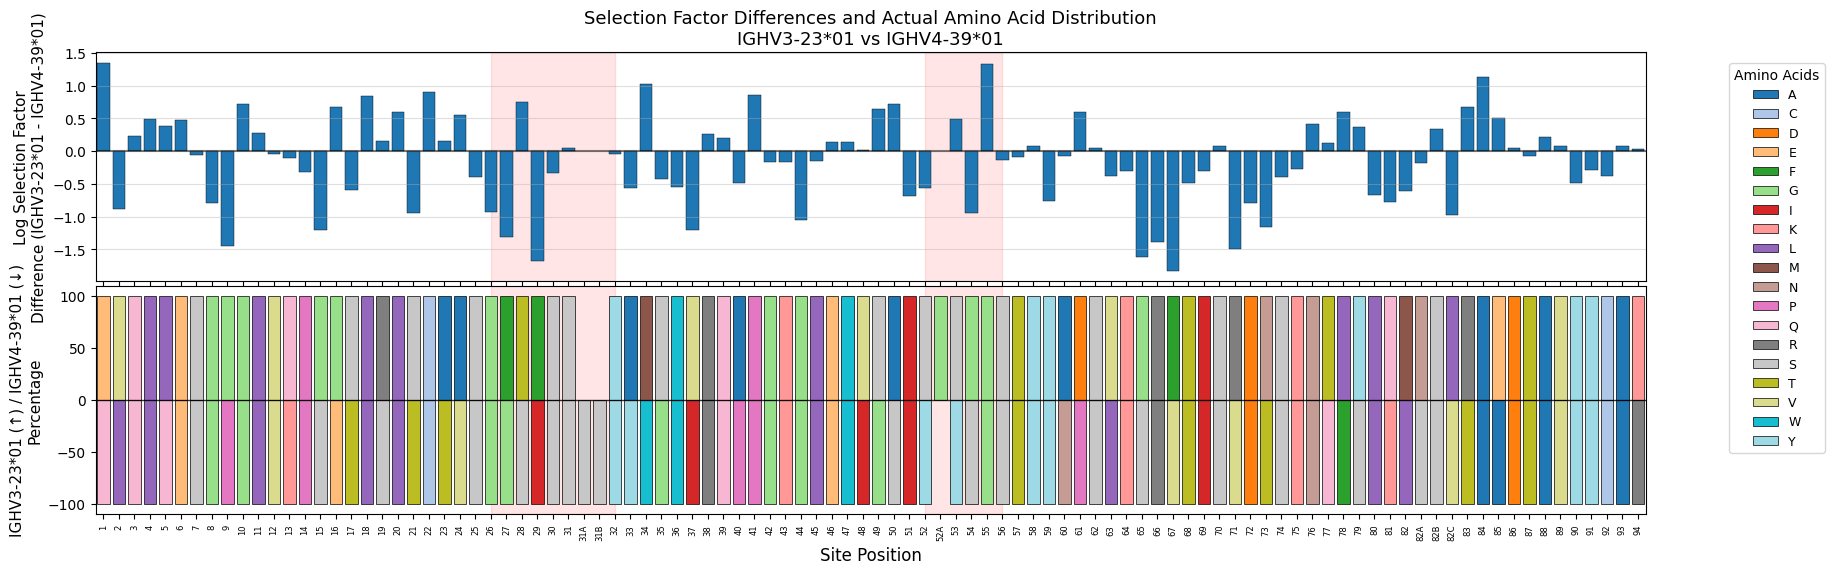

In [30]:
# compare two most common v genes to show that selection differences are not driven just by different germline amino acids but also by epistasis.
def combined_vgene_plots_actual_aa(v_gene1, v_gene2, site_sub_probs_df_germline, 
                                  numbering_scheme='imgt', figsize=(20, 6)):
    """
    Create combined plots comparing V genes:
    - Top: Selection factor differences (bar plot)
    - Bottom: Mirrored amino acid distribution from actual data (parent_aa column)
    Both plots share the same x-axis
    
    Parameters:
    -----------
    v_gene1 : str
        First V gene name
    v_gene2 : str
        Second V gene name
    site_sub_probs_df_germline : pd.DataFrame
        DataFrame with selection factors including parent_aa column
    numbering_scheme : str
        Either 'imgt' or 'chothia' (default: 'imgt')
    figsize : tuple
        Figure size (default: (20, 6))
    """
    from utils import sort_antibody_sites, add_cdr_shading
    
    # Ensure site column is string
    site_sub_probs_df_germline = site_sub_probs_df_germline.copy()
    site_sub_probs_df_germline['site'] = site_sub_probs_df_germline['site'].astype(str)
    
    # Prepare selection factor data (keep parent_aa in groupby)
    df = site_sub_probs_df_germline[site_sub_probs_df_germline.v_gene.isin([v_gene1, v_gene2])].copy()
    df = df[df['is_germline_codon'] == True]
    df['site'] = df['site'].astype(str)
    
    # Group by site and parent_aa (not by is_cdr)
    median_log_selection_factors_1 = df[(df.v_gene == v_gene1)].groupby(['site', 'parent_aa']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_2 = df[(df.v_gene == v_gene2)].groupby(['site', 'parent_aa']).log_selection_factor.median().reset_index().copy()
    
    # Ensure site is string
    median_log_selection_factors_1['site'] = median_log_selection_factors_1['site'].astype(str)
    median_log_selection_factors_2['site'] = median_log_selection_factors_2['site'].astype(str)
    
    # Merge on site (this will keep parent_aa columns with suffixes)
    median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, 
                                                    on='site', how='inner', suffixes=('_1', '_2'))
    
    # Calculate difference
    median_log_selection_factors_compare['difference'] = (median_log_selection_factors_compare['log_selection_factor_1'] - 
                                                         median_log_selection_factors_compare['log_selection_factor_2'])
    
    # Get all sites and sort them properly
    family1_data = df[df.v_gene == v_gene1].copy()
    family2_data = df[df.v_gene == v_gene2].copy()
    
    all_sites_with_data = sorted(set(family1_data['site'].unique()) | set(family2_data['site'].unique()))
    sorted_sites = sort_antibody_sites(all_sites_with_data)
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    if len(sorted_sites) == 0:
        print("Warning: No data found for one or both V genes")
        return None, None, None
    
    # Create subplots with shared x-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.02})
    
    # Add CDR shading to both plots
    add_cdr_shading(ax1, sorted_sites, numbering_scheme=numbering_scheme)
    add_cdr_shading(ax2, sorted_sites, numbering_scheme=numbering_scheme)
    
    # ===== TOP PLOT: SELECTION FACTOR DIFFERENCES =====
    
    # Map sites to positions and plot bars with single color
    median_log_selection_factors_compare['site_position'] = median_log_selection_factors_compare['site'].map(site_to_position)
    ax1.bar(median_log_selection_factors_compare['site_position'], 
            median_log_selection_factors_compare['difference'], 
            color='#1f77b4', width=0.8, edgecolor='black', linewidth=0.3)
    
    # Customize top plot
    ax1.set_ylabel(f'Log Selection Factor\nDifference ({v_gene1} - {v_gene2})', fontsize=11)
    ax1.set_title(f'Selection Factor Differences and Actual Amino Acid Distribution\n{v_gene1} vs {v_gene2}', fontsize=13)
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax1.grid(True, alpha=0.4, linewidth=0.8, axis='y')
    
    # ===== BOTTOM PLOT: MIRRORED AMINO ACID DISTRIBUTION FROM ACTUAL DATA =====
    
    # Get all unique amino acids from both genes (from parent_aa column)
    all_amino_acids = sorted(set(family1_data['parent_aa'].unique()) | 
                           set(family2_data['parent_aa'].unique()))
    
    # Use tab20 colormap
    aa_colors = plt.cm.tab20(np.linspace(0, 1, len(all_amino_acids)))
    color_map = dict(zip(all_amino_acids, aa_colors))
    
    # Calculate percentages for gene1 at specific sites
    family1_site_counts = {}
    for aa in all_amino_acids:
        aa_data = family1_data[family1_data['parent_aa'] == aa]
        site_counts = aa_data['site'].value_counts()
        family1_site_counts[aa] = site_counts
    
    # Calculate percentages for gene2 at specific sites  
    family2_site_counts = {}
    for aa in all_amino_acids:
        aa_data = family2_data[family2_data['parent_aa'] == aa]
        site_counts = aa_data['site'].value_counts()
        family2_site_counts[aa] = site_counts
    
    # Plot gene1 above x-axis (positive values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom1 = 0
        site_total = sum([family1_site_counts[aa].get(site, 0) for aa in all_amino_acids])
        
        for aa in all_amino_acids:
            count = family1_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = (count / site_total) * 100
                ax2.bar(site_pos, percentage, bottom=bottom1, 
                       color=color_map[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom1 += percentage
    
    # Plot gene2 below x-axis (negative values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom2 = 0
        site_total = sum([family2_site_counts[aa].get(site, 0) for aa in all_amino_acids])
        
        for aa in all_amino_acids:
            count = family2_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = -(count / site_total) * 100  # Negative for below x-axis
                ax2.bar(site_pos, percentage, bottom=bottom2, 
                       color=color_map[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom2 += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'{v_gene1} (↑) / {v_gene2} (↓)\nPercentage', fontsize=11)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in all_amino_acids:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_map[aa], 
                                          edgecolor='black', linewidth=0.5))
        legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, bbox_to_anchor=(1.05, 2), loc='upper left', 
              title='Amino Acids', fontsize=9)
    
    # Set x-axis ticks and labels with sorted sites
    ax1.set_xticks(range(len(sorted_sites)))
    ax2.set_xticks(range(len(sorted_sites)))
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax2.set_xlim(-0.5, len(sorted_sites) - 0.5)
    
    # Only show x-tick labels on bottom plot with small font
    ax1.set_xticklabels([])
    ax2.set_xlabel('Site Position', fontsize=12)
    ax2.set_xticklabels(sorted_sites, rotation=90, fontsize=6)
    
    plt.tight_layout()
    plt.show()
    
    return median_log_selection_factors_compare, fig, (ax1, ax2)

# Usage:
most_common_v3_gene = site_sub_probs_df[site_sub_probs_df.v_family == 'IGHV3'].v_gene.value_counts().idxmax()
most_common_v4_gene = site_sub_probs_df[site_sub_probs_df.v_family == 'IGHV4'].v_gene.value_counts().idxmax()
result_df, fig, (ax1, ax2) = combined_vgene_plots_actual_aa(most_common_v3_gene, most_common_v4_gene, site_sub_probs_df, numbering_scheme=numbering_scheme)
#fig.savefig(f'{figures_dir}/IGHV3-23_vs_IGHV4-39_selection_and_aa_distribution.pdf', dpi=800, bbox_inches='tight', format='pdf')

In [31]:
result_df['same_parent_aa'] = result_df.parent_aa_1 != result_df.parent_aa_2
result_df[result_df.difference.abs() > 1].groupby('same_parent_aa').size() / result_df[result_df.difference.abs() > 1].shape[0] * 100


same_parent_aa
False    26.666667
True     73.333333
dtype: float64

In [32]:
result_df['abs_difference'] = result_df.difference.abs()
result_df.groupby('same_parent_aa')['abs_difference'].median()

same_parent_aa
False    0.315219
True     0.616450
Name: abs_difference, dtype: float64

# Are some v genes more evolvable than others?


In [37]:
def get_evolvability_of_vgene(v_gene1, site_sub_probs_df_germline, numbering_scheme='imgt', 
                              figsize=(13, 5), limit_pcp_depth=True):
    """
    Plot evolvability (median log selection factor) for a single V gene.
    
    Parameters:
    -----------
    v_gene1 : str
        V gene name
    site_sub_probs_df_germline : pd.DataFrame
        DataFrame with selection factors
    numbering_scheme : str
        Either 'imgt' or 'chothia' (default: 'imgt')
    figsize : tuple
        Figure size (default: (13, 5))
    limit_pcp_depth : bool
        If True, limit to pcps at depth 2 (default: True)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes
    """
    from utils import sort_antibody_sites, add_cdr_shading
    
    # Ensure site column is string
    site_sub_probs_df_germline = site_sub_probs_df_germline.copy()
    site_sub_probs_df_germline['site'] = site_sub_probs_df_germline['site'].astype(str)
    
    # Filter data
    df = site_sub_probs_df_germline[site_sub_probs_df_germline.v_gene == v_gene1].copy()
    df = df[df['is_germline_codon'] == True]

    if limit_pcp_depth:
        # Limit to only pcps that are 2 levels away from the naive, which are likely the most reliable
        df = df[df.depth == 2]

    # Group by site only (not by is_cdr)
    median_log_selection_factors_1 = df.groupby('site').log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_1['site'] = median_log_selection_factors_1['site'].astype(str)
    
    print(f"Median log selection factor for {v_gene1}: {median_log_selection_factors_1.log_selection_factor.median():.3f}")

    # Sort sites properly
    sorted_sites = sort_antibody_sites(median_log_selection_factors_1['site'].unique())
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Add CDR shading
    add_cdr_shading(ax, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Map sites to positions
    median_log_selection_factors_1['site_position'] = median_log_selection_factors_1['site'].map(site_to_position)
    
    # Create barplot with single color
    ax.bar(median_log_selection_factors_1['site_position'], 
           median_log_selection_factors_1['log_selection_factor'],
           color='#1f77b4', width=0.8, edgecolor='black', linewidth=0.3)
    
    # Customize the plot
    ax.set_ylabel('Log Selection Factor', fontsize=12)
    ax.set_xlabel('Site', fontsize=12)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax.set_title(f'Evolvability of {v_gene1}', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set x-axis ticks and labels
    ax.set_xticks(range(len(sorted_sites)))
    ax.set_xticklabels(sorted_sites, rotation=90, fontsize=8)
    ax.set_xlim(-0.5, len(sorted_sites) - 0.5)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

Median log selection factor for IGHV3-23*01: -0.908


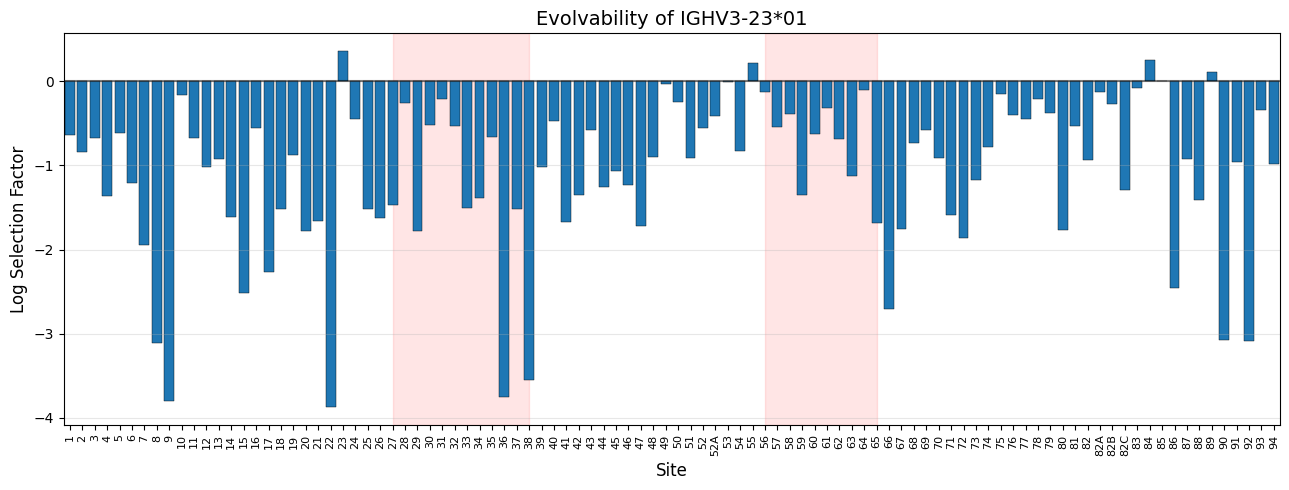

Median log selection factor for IGHV3-66*02: -0.864


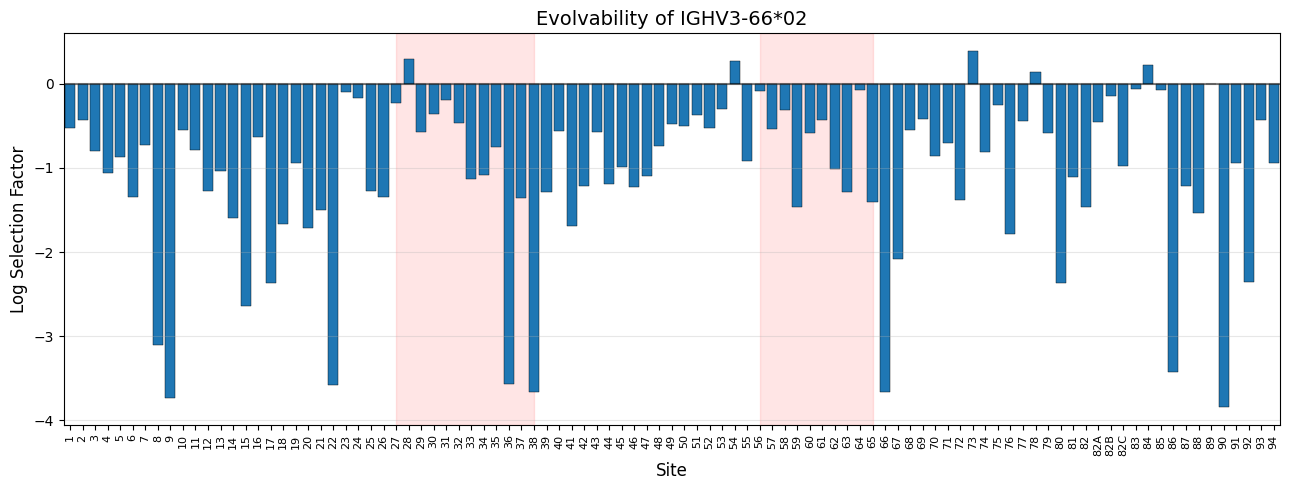

(<Figure size 1300x500 with 1 Axes>,
 <Axes: title={'center': 'Evolvability of IGHV3-66*02'}, xlabel='Site', ylabel='Log Selection Factor'>)

In [38]:
get_evolvability_of_vgene('IGHV3-23*01', site_sub_probs_df)
get_evolvability_of_vgene('IGHV3-66*02', site_sub_probs_df)

In [23]:
def get_evolvability_of_vgenes(site_sub_probs_df_germline, limit_pcp_depth=True):
    df = site_sub_probs_df_germline[site_sub_probs_df_germline['is_germline_codon'] == True].copy()
    df.sort_values(by='v_gene', inplace=True)

    if limit_pcp_depth:
        # Limit to only pcps that are 2 levels away from the naive, which are likely the most reliable
        df = df[df.depth == 2]

    # Create two subplots in a column
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20,8), sharex=True)
    
    # Plot CDR sites (True) on first subplot
    sns.boxplot(data=df[df.is_cdr == True], x='v_gene', y='log_selection_factor', 
                hue='v_family', showfliers=False, ax=ax2)
    ax2.set_title('CDR Sites', fontsize=14)
    ax2.set_xlabel('')  # Remove x-label from top plot
    ax2.legend(loc='upper right', title='V Family', fontsize=10, title_fontsize=12, 
               bbox_to_anchor=(1.1, 0.5), borderaxespad=0.)
    
    # Plot FWR sites (False) on second subplot
    sns.boxplot(data=df[df.is_cdr == False], x='v_gene', y='log_selection_factor', 
                hue='v_family', showfliers=False, ax=ax1)
    ax1.set_title('FWR Sites', fontsize=14)
    ax1.get_legend().remove()
    
    # Rotate x-axis labels on bottom plot only (since sharex=True, both will rotate)
    plt.setp(ax2.get_xticklabels(), rotation=90, ha='center')
    
    plt.tight_layout()
    plt.show()
    
    return fig, (ax1, ax2)


def get_evolvability_of_vgenes2(site_sub_probs_df_germline, limit_pcp_depth=True):
    df = site_sub_probs_df_germline[site_sub_probs_df_germline['is_germline_codon'] == True].copy()
    df.sort_values(by='v_gene', inplace=True)

    if limit_pcp_depth:
        # Limit to only pcps that are 2 levels away from the naive, which are likely the most reliable
        df = df[df.depth == 2]

    # Create two subplots in a column
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20,8), sharex=True)
    
    # Plot CDR sites (True) on first subplot
    sns.boxplot(data=df[(df.is_cdr == True) & (df.site.isin(list(range(27,39))))], x='v_gene', y='log_selection_factor', 
                hue='v_family', showfliers=False, ax=ax2)
    ax2.set_title('CDR1 Sites', fontsize=14)
    ax2.set_xlabel('')  # Remove x-label from top plot
    ax2.legend(loc='upper right', title='V Family', fontsize=10, title_fontsize=12, 
               bbox_to_anchor=(1.1, 0.5), borderaxespad=0.)
    
    # Plot CDR2 sites on second subplot
    sns.boxplot(data=df[(df.is_cdr == True) & (df.site.isin(list(range(56,66))))], x='v_gene', y='log_selection_factor', 
                hue='v_family', showfliers=False, ax=ax1)
    ax1.set_title('CDR2 Sites', fontsize=14)
    ax1.get_legend().remove()
    
    # Rotate x-axis labels on bottom plot only (since sharex=True, both will rotate)
    plt.setp(ax2.get_xticklabels(), rotation=90, ha='center')
    
    plt.tight_layout()
    plt.show()
    
    return fig, (ax1, ax2)




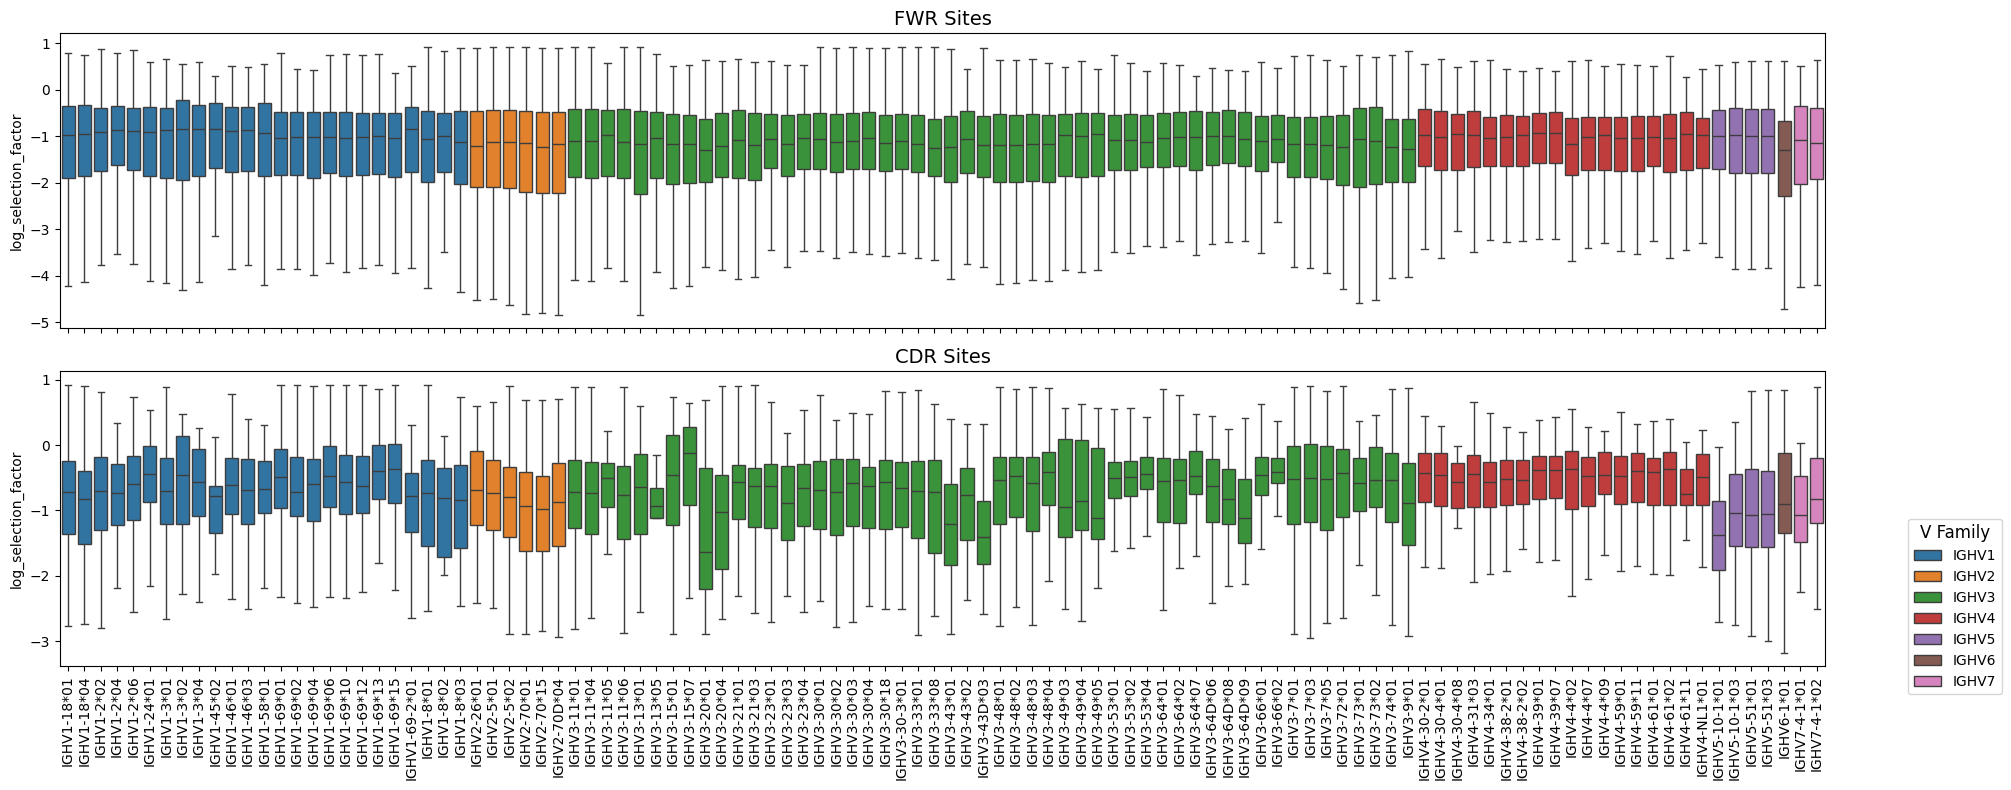

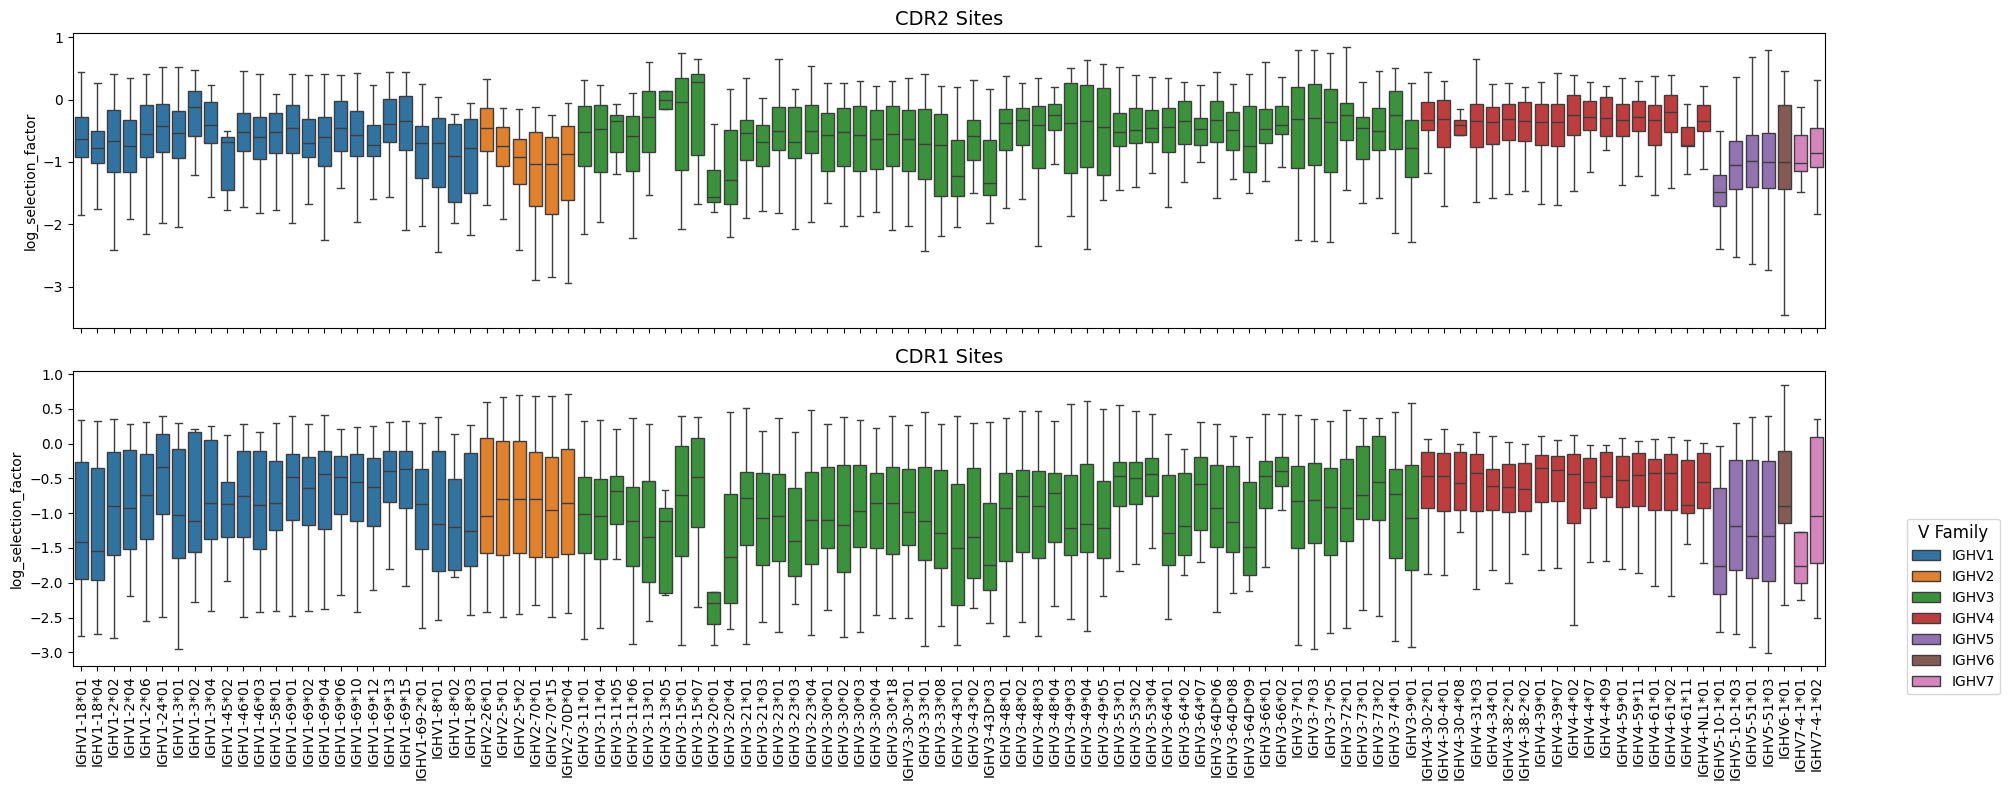

In [24]:
fig, ax = get_evolvability_of_vgenes(site_sub_probs_df)
fig, ax = get_evolvability_of_vgenes2(site_sub_probs_df)

#fig, ax = get_evolvability_of_vgenes(site_sub_probs_df, limit_pcp_depth=False)

Text(0.5, 1.0, 'Correlation between V Gene Counts in Test data set and CDR Selection Factor')

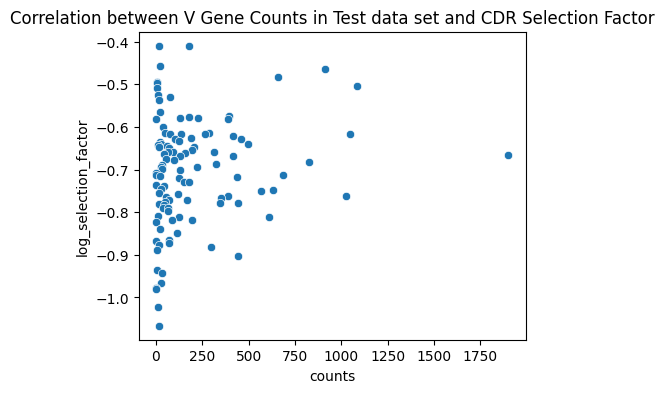

In [25]:
## is this tied to how much data there is for each v gene?

v_gene_median_cdr_selection_factors = site_sub_probs_df[site_sub_probs_df.is_cdr == True].groupby('v_gene').log_selection_factor.median().sort_values(ascending=False).reset_index()
v_gene_counts = site_sub_probs_df[['v_gene', 'pcp_index']].drop_duplicates().groupby('v_gene').size().reset_index().rename(columns={0: 'counts'})

to_plot = pd.merge(v_gene_median_cdr_selection_factors, v_gene_counts, on='v_gene')
fig, ax = plt.subplots(figsize=(5, 4))

# plot correlation between log_selection_factor and counts
sns.scatterplot(data=to_plot, x='counts', y='log_selection_factor', ax=ax)
ax.set_title('Correlation between V Gene Counts in Test data set and CDR Selection Factor')



Text(0.5, 1.0, 'Correlation between V Gene Counts in Training Set and CDR Selection Factor')

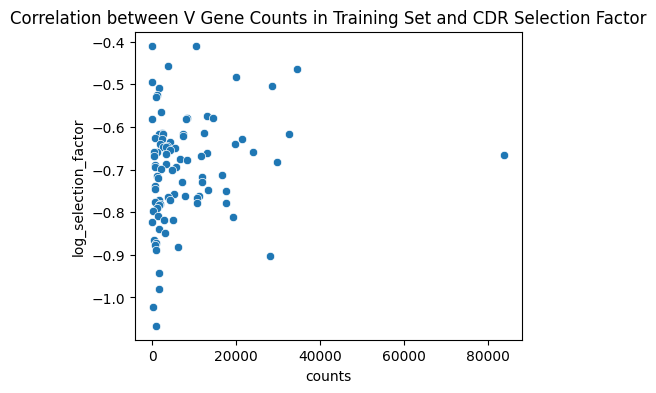

In [26]:
## is this tied to how much data there is for each v gene in the training set?

pcp_df_train1 = load_pcp_df(localify("DATA_DIR/v3/tang-deepshm-prod-NoWinCheck_igh_pcp_2024-10-29_MASKED_NI_noN_no-naive.csv.gz"))
pcp_df_train2 = load_pcp_df(localify("DATA_DIR/v3/wyatt-10x-1p5m_fs-all-NoWinCheck_igh_pcp_2024-10-29_NI_noN_no-naive.csv.gz"))

pcp_train_vgene_counts = pd.concat([pcp_df_train1, pcp_df_train2]).groupby('v_gene_heavy').size().reset_index().rename(columns={0: 'counts', 'v_gene_heavy': 'v_gene'})


v_gene_median_cdr_selection_factors = site_sub_probs_df[site_sub_probs_df.is_cdr == True].groupby('v_gene').log_selection_factor.median().sort_values(ascending=False).reset_index()

to_plot = pd.merge(v_gene_median_cdr_selection_factors, pcp_train_vgene_counts, on='v_gene')
# plot correlation between log_selection_factor and counts
fig, ax = plt.subplots(figsize=(5, 4))
sns.scatterplot(data=to_plot, x='counts', y='log_selection_factor', ax=ax)
ax.set_title('Correlation between V Gene Counts in Training Set and CDR Selection Factor')


Text(0.5, 1.0, 'Correlation between V Gene Counts in Test and Training Set')

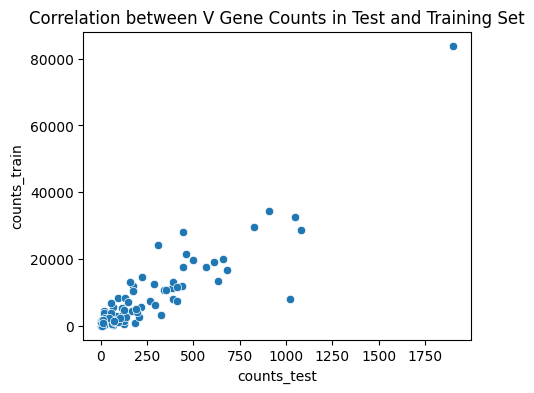

In [27]:
# correlation between counts in test and training set
to_plot = pd.merge(v_gene_counts, pcp_train_vgene_counts, on='v_gene', suffixes=('_test', '_train'))
fig, ax = plt.subplots(figsize=(5, 4))
sns.scatterplot(data=to_plot, x='counts_test', y='counts_train', ax=ax)
ax.set_title('Correlation between V Gene Counts in Test and Training Set')

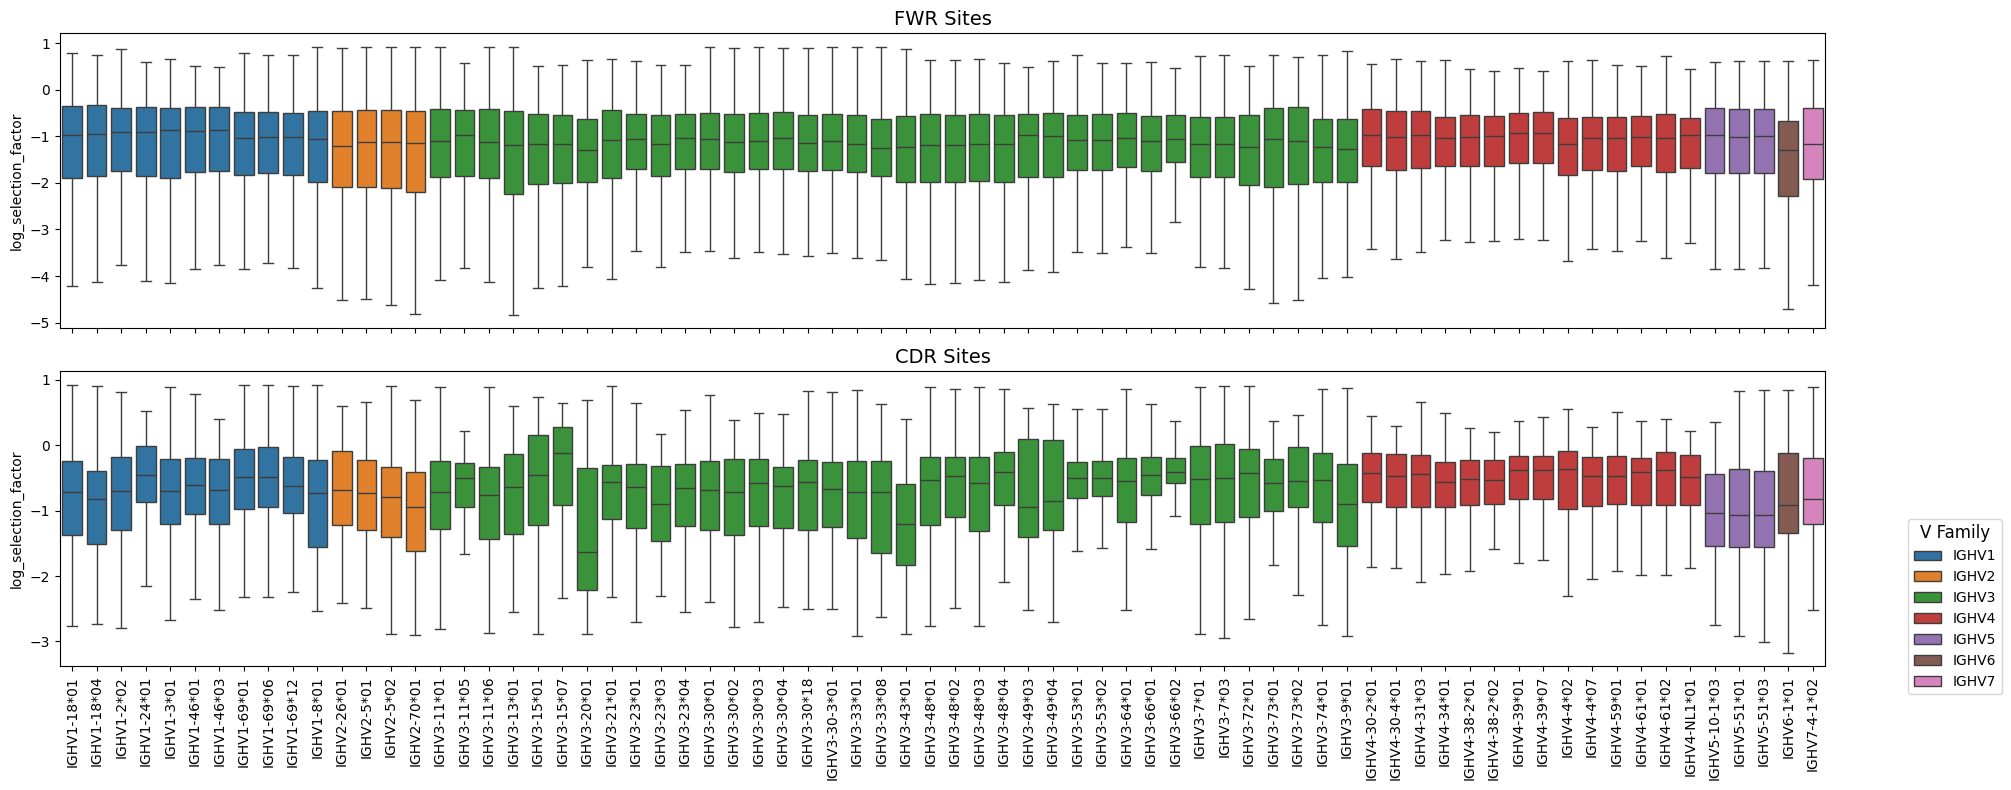

In [28]:
# filter for genes that appear more than 1000 times in the training set
common_v_genes = pcp_train_vgene_counts[pcp_train_vgene_counts.counts > 1000].v_gene.tolist()
fig, ax = get_evolvability_of_vgenes(site_sub_probs_df[site_sub_probs_df.v_gene.isin(common_v_genes)])


## How much selection difference is there between v genes of the same family vs different families?

In [29]:
# calculate distance between v genes

def calculate_similarity(df, level="nucleotide", metric="hamming"):
    """
    Calculate pairwise similarity between v_genes using nucleotides or amino acids,
    with Hamming or Levenshtein distance. Missing codons are treated as gaps.
    
    Args:
        df : DataFrame with columns ['v_gene', 'site', 'codon']
        level : str, "nucleotide" or "aa"
        metric : str, "hamming" or "levenshtein"
        
    Returns:
        similarity_matrix : pandas DataFrame
    """
    
    # Pivot into codon matrix (missing codons remain NaN)
    codon_matrix = df.pivot(index='v_gene', columns='site', values='codon')
    
    if level == "aa":
        # Translate codons using Biopython
        def translate_codon(c):
            if pd.isnull(c):
                return '-'  # gap
            try:
                return str(Seq(c).translate(to_stop=False))
            except:
                return 'X'  # unknown codon
        
        matrix = codon_matrix.applymap(translate_codon)
        # Concatenate amino acids into sequences
        seqs = matrix.apply(lambda row: ''.join(row.values), axis=1)
        
    elif level == "nucleotide":
        # Split codons into individual nucleotides
        def split_codon(c):
            if pd.isnull(c):
                return ['-','-','-']  # gap for missing codon
            return list(c)
        
        # Expand each codon column into 3 nucleotide columns
        nuc_matrix = pd.DataFrame(index=codon_matrix.index)
        for col in codon_matrix.columns:
            split_cols = codon_matrix[col].apply(split_codon)
            nuc_matrix = pd.concat([nuc_matrix, pd.DataFrame(split_cols.tolist(),
                                                             index=codon_matrix.index,
                                                             columns=[f"{col}_1", f"{col}_2", f"{col}_3"])],
                                   axis=1)
        # Concatenate nucleotides into full sequences
        seqs = nuc_matrix.apply(lambda row: ''.join(row.values), axis=1)
    
    else:
        raise ValueError("level must be 'nucleotide' or 'aa'")
    
    # Initialize similarity matrix
    indices = seqs.index
    similarity_matrix = pd.DataFrame(index=indices, columns=indices, dtype=float)
    
    # Pairwise comparisons
    for gene1, gene2 in combinations(indices, 2):
        s1, s2 = seqs[gene1], seqs[gene2]
        
        if metric == "hamming":
            paired = [(a, b) for a, b in zip(s1, s2) if a != '-' and b != '-']
            if len(paired) == 0:
                similarity = np.nan
            else:
                identical = sum(a == b for a, b in paired)
                similarity = identical / len(paired)
        
        elif metric == "levenshtein":
            dist = lev_distance(s1, s2)
            max_len = max(len(s1), len(s2))
            similarity = 1 - (dist / max_len if max_len > 0 else 0.0)
        
        else:
            raise ValueError("metric must be 'hamming' or 'levenshtein'")
        
        similarity_matrix.loc[gene1, gene2] = similarity
        similarity_matrix.loc[gene2, gene1] = similarity
    
    # Self-similarity = 1
    np.fill_diagonal(similarity_matrix.values, 1.0)
    
    return similarity_matrix


distance_hamming_nucleotide = calculate_similarity(germline_codons_df, level="nucleotide", metric="hamming")
distance_hamming_aa = calculate_similarity(germline_codons_df, level="aa", metric="hamming")
distance_levenshtein_nucleotide = calculate_similarity(germline_codons_df, level="nucleotide", metric="levenshtein")
distance_levenshtein_aa = calculate_similarity(germline_codons_df, level="aa", metric="levenshtein")


/tmp/ipykernel_302560/2208673091.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix = codon_matrix.applymap(translate_codon)
/tmp/ipykernel_302560/2208673091.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix = codon_matrix.applymap(translate_codon)


In [30]:
### How much does germline identity effect selection factors?

## germline similarity vs. epistasis correrlation
## This is an analysis we attempted. The problem here is that the germline similarity doesn't only effect the correlation in the identical sites, it also effects the number of sites that we can test. 
## If we want to do this analysis, it may be better to do it with DNSM and not separate the sites to group 1 and group 2 - similar to the V3 vs V4 analysis in the DNSM paper, just gene-wise.


v_genes_to_test = pcp_df[pcp_df.groupby('v_gene')['v_gene'].transform('count') > 200].v_gene.drop_duplicates().to_list()

#v_genes_to_test = ['IGHV3-21*01', 'IGHV3-15*01', 'IGHV4-59*01', 'IGHV4-34*01', 'IGHV3-30*02', 'IGHV3-30*01']

epistatic_correlation_results = []


def epistatic_correlation(site_sub_probs_df, v_family1, v_family2, vcolumn='v_gene', is_germline=False, lower_log_selection_factor_lim=-5):
    '''
    vcolumn: column to use for v family comparison, e.g. 'v_family' or 'v_gene'
    '''
    df = site_sub_probs_df.copy()
    if is_germline == 'codon':
        df = df[df['is_germline_codon'] == True]
    elif is_germline == 'aa':
        df = df[df['is_germline_aa'] == True]

    median_log_selection_factors_1 = df[(df[vcolumn] == v_family1)].groupby(['site']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_2 = df[(df[vcolumn] == v_family2)].groupby(['site']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site'], how='inner', suffixes=('_1', '_2'))

    # Drop NaN values for comparison
    clean_df = median_log_selection_factors_compare.dropna(subset=['log_selection_factor_1', 'log_selection_factor_2'])

    # Trim values below lower_log_selection_factor_lim
    clean_df_trimmed = clean_df.copy()
    clean_df_trimmed['log_selection_factor_1'] = clean_df_trimmed['log_selection_factor_1'].clip(lower=lower_log_selection_factor_lim)
    clean_df_trimmed['log_selection_factor_2'] = clean_df_trimmed['log_selection_factor_2'].clip(lower=lower_log_selection_factor_lim)

    # Calculate R-squared for original data
    r_original, p_original = pearsonr(clean_df_trimmed['log_selection_factor_1'], 
                                    clean_df_trimmed['log_selection_factor_2'])
    r_squared_original = r_original**2

    return r_squared_original, p_original




for i in tqdm(v_genes_to_test):
    for j in v_genes_to_test:
        if i != j and i < j:
            r_squared_original, p_original = epistatic_correlation(site_sub_probs_df, i, j, is_germline=False,  lower_log_selection_factor_lim=-5)
            epistatic_correlation_results.append((i, j, r_squared_original, p_original))

epistatic_correlation_results = pd.DataFrame(epistatic_correlation_results, columns=['v_gene1', 'v_gene2', 'r_squared', 'p_value']).sort_values(by='r_squared', ascending=False)

100%|██████████| 31/31 [05:46<00:00, 11.18s/it]


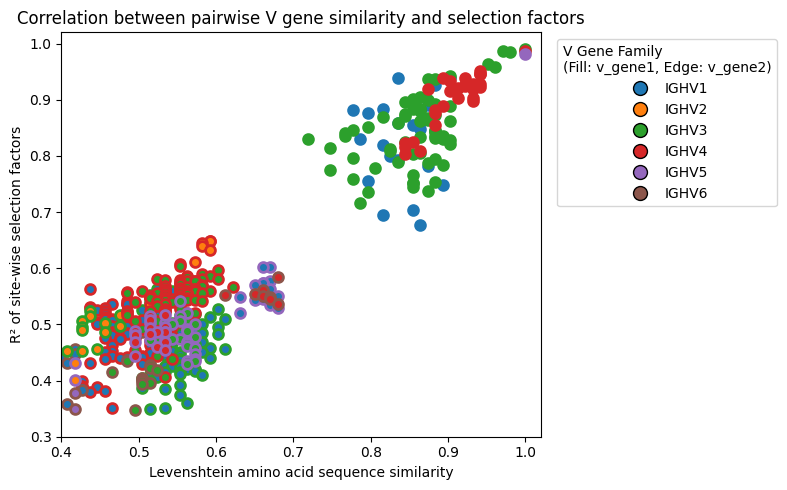

In [31]:
# Plot selection correlation vs. germline similarity
fig, ax = plt.subplots(figsize=(8, 5))

# Prepare your data
melted_df = distance_levenshtein_aa.reset_index().melt(id_vars=['v_gene'], 
                    var_name='v_gene2', 
                    value_name='sequence_similarity').rename(columns={'v_gene': 'v_gene1'})
melted_df['v_family1'] = melted_df.v_gene1.str.extract(r'^(IGHV\d+)')
melted_df['v_family2'] = melted_df.v_gene2.str.extract(r'^(IGHV\d+)')
melted_df['same_family'] = melted_df.v_family1 == melted_df.v_family2

# Merge with your correlation results
plot_data = pd.merge(epistatic_correlation_results, melted_df, on=['v_gene1', 'v_gene2'])

# Use tab20 colormap for more distinct colors
tab20_colors = plt.cm.tab20(np.linspace(0, 1, 20))

# Define colors for each V family using tab20
family_colors = {
    'IGHV1': tab20_colors[0],   # Blue
    'IGHV2': tab20_colors[2],   # Orange  
    'IGHV3': tab20_colors[4],   # Green
    'IGHV4': tab20_colors[6],   # Red
    'IGHV5': tab20_colors[8],   # Purple
    'IGHV6': tab20_colors[10],  # Brown
    'IGHV7': tab20_colors[12],  # Pink
    'IGHV8': tab20_colors[14],  # Gray
}

# Group by combinations of families
for (v_fam1, v_fam2), group in plot_data.groupby(['v_family1', 'v_family2']):
    if len(group) == 0:
        continue
    
    facecolor = family_colors.get(v_fam1, '#CCCCCC')
    edgecolor = family_colors.get(v_fam2, '#CCCCCC')
    
    ax.scatter(group['sequence_similarity'], group['r_squared'],
              facecolor=facecolor, edgecolor=edgecolor, 
              s=50, linewidth=2)

# Create custom legend for V families (fill colors)
family_legend_elements = []
for family, color in family_colors.items():
    if family in plot_data['v_family1'].values or family in plot_data['v_family2'].values:
        family_legend_elements.append(
            plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=color, markeredgecolor='black',
                      markersize=10, markeredgewidth=1, label=family)
        )

# Add legend
ax.legend(handles=family_legend_elements, title='V Gene Family\n(Fill: v_gene1, Edge: v_gene2)', 
         loc='upper left', bbox_to_anchor=(1.02, 1))

ax.set_title('Correlation between pairwise V gene similarity and selection factors')
ax.set_ylabel('R² of site-wise selection factors')
ax.set_xlabel('Levenshtein amino acid sequence similarity')
ax.set_ylim(0.3, 1.02)
ax.set_xlim(0.4, 1.02)

plt.tight_layout()
plt.show()
fig.savefig(f'{figures_dir}/v_gene_seq_similarity_vs_selection_correlation.pdf', dpi=800, bbox_inches='tight', format='pdf')

In [32]:
plot_data.groupby('same_family').agg({'r_squared': ['median'], 'sequence_similarity': ['median']})

,r_squared,sequence_similarity
,median,median
same_family,,
False,0.497467,0.533981
True,0.861987,0.868932


## GRAB motifs 

### V gene level analysis

In [7]:
grab_motifs_from_paper = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/grab_motifs/grab_motifs_human_ighv_chothia_to_imgt_mapping.csv')


# Count occurrences of each v_gene
v_gene_counts = site_sub_probs_df[site_sub_probs_df.is_germline_codon == True][['v_gene', 'pcp_index']].drop_duplicates().v_gene.value_counts()
frequent_v_genes = v_gene_counts[v_gene_counts > 50].index

# Filter for frequent v_genes and then calculate median
median_log_selection_factors = site_sub_probs_df[
    (site_sub_probs_df.is_germline_codon == True) & 
    (site_sub_probs_df.v_gene.isin(frequent_v_genes))
].groupby(['site', 'is_cdr', 'parent_aa', 'v_gene', 'v_family']).log_selection_factor.median().reset_index().copy()



grab_motifs = pd.merge(median_log_selection_factors, grab_motifs_from_paper[['v_gene', 'amino_acid', 'imgt_position', 'Antibody_GRAB_motif_full']].rename(columns={'amino_acid': 'parent_aa', 'imgt_position': 'site'}), on=['v_gene', 'parent_aa', 'site'], how='left')


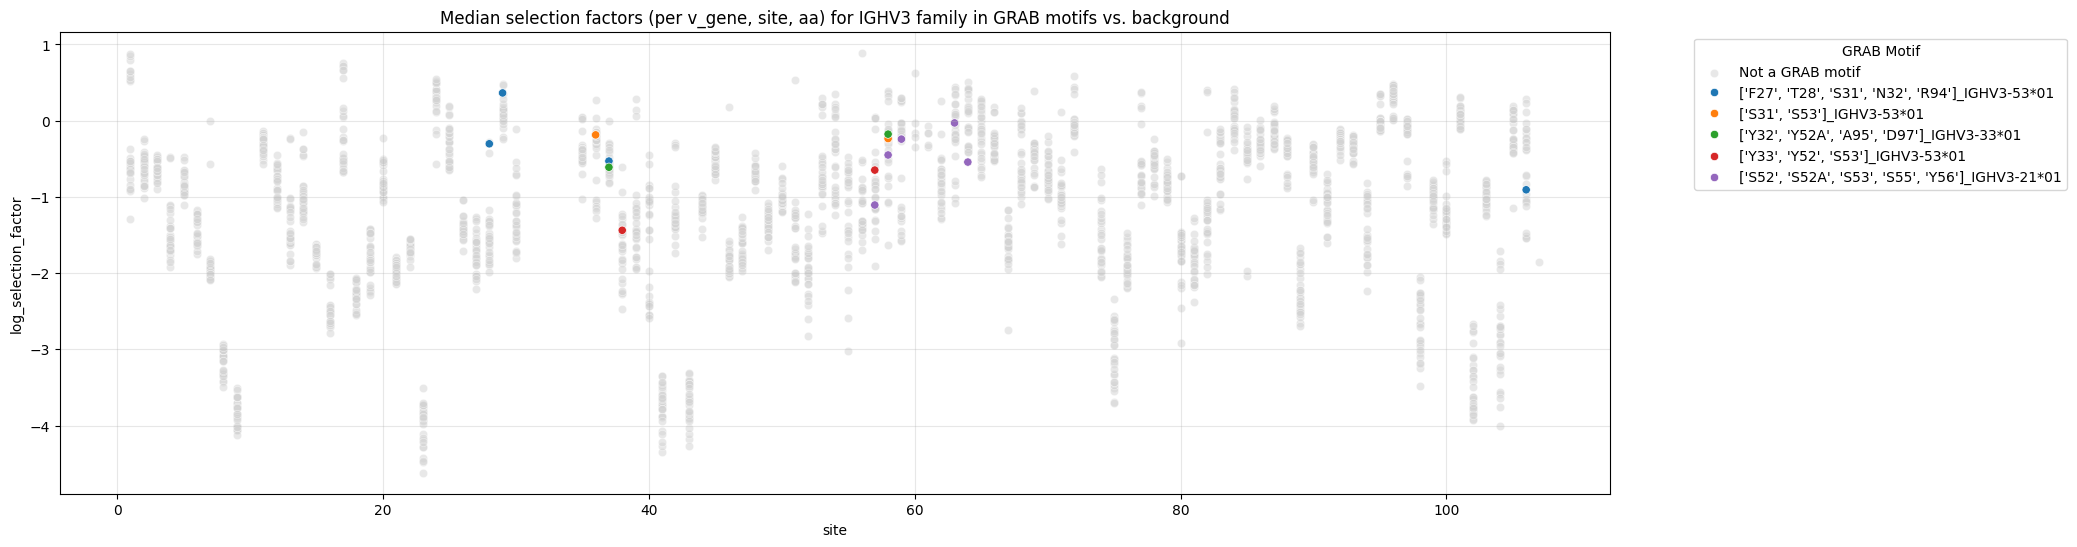

In [8]:
# Filter for IGHV3 family
ighv3_data = grab_motifs[grab_motifs.v_family == 'IGHV3']
ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] = \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] + '_' + \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'v_gene']

# Separate data into background (null motif) and GRAB motif
background_data = ighv3_data[ighv3_data.Antibody_GRAB_motif_full.isnull()]
grab_data = ighv3_data[ighv3_data.Antibody_GRAB_motif_full.notnull()]

# Create the plot
fig, ax = plt.subplots(figsize=(20, 6))

# Plot background data in grey first (so it appears behind)
sns.scatterplot(data=background_data, x='site', y='log_selection_factor', 
                color='lightgrey', alpha=0.5, label='Not a GRAB motif', ax=ax)

# Plot GRAB motif data with color coding
sns.scatterplot(data=grab_data, x='site', y='log_selection_factor', 
                hue='Antibody_GRAB_motif_full', ax=ax)

ax.legend(title='GRAB Motif', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Median selection factors (per v_gene, site, aa) for IGHV3 family in GRAB motifs vs. background')
ax.grid(True, alpha=0.3)

plt.show()

/tmp/ipykernel_302560/715889438.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


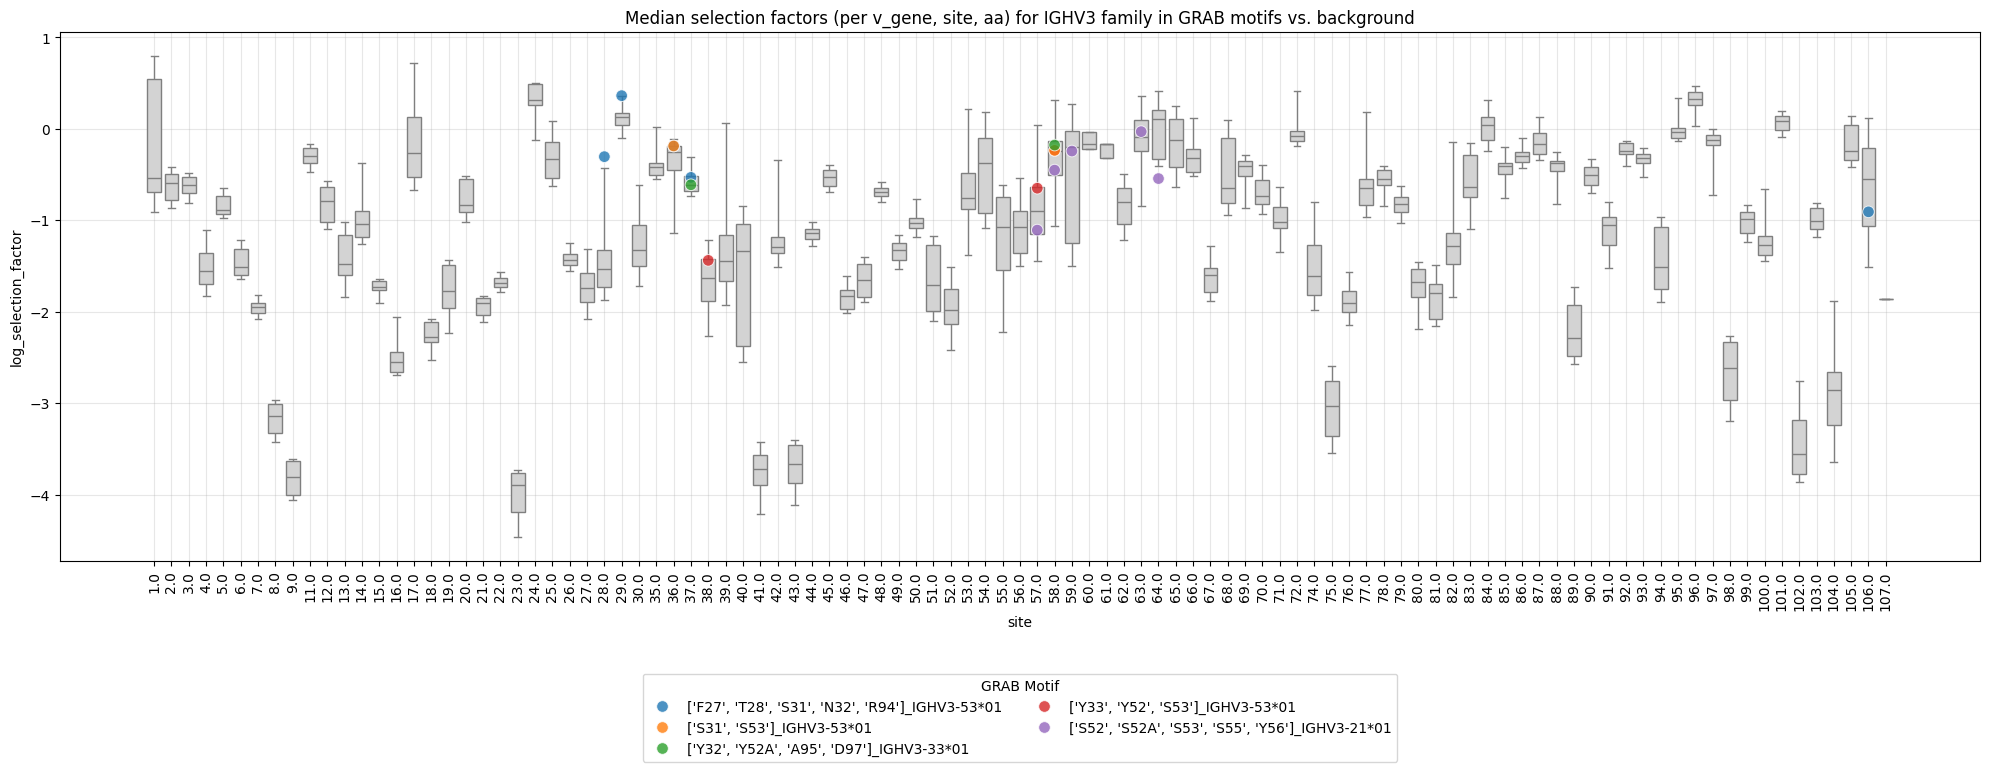

In [35]:
# Filter for IGHV3 family
ighv3_data = grab_motifs[grab_motifs.v_family == 'IGHV3'].copy()
ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] = \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] + '_' + \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'v_gene']

# Convert site to string to ensure categorical treatment
ighv3_data['site'] = ighv3_data['site'].astype(str)

# Separate data into background (null motif) and GRAB motif
grab_data = ighv3_data[ighv3_data.Antibody_GRAB_motif_full.notnull()]

# Create the plot
fig, ax = plt.subplots(figsize=(20, 8))

# Plot boxplot for all data (background distribution per site)
sns.boxplot(data=ighv3_data, x='site', y='log_selection_factor', 
            color='lightgrey', ax=ax, showfliers=False, whis=[5, 95])

# Overlay GRAB motif data as colored scatter points
sns.scatterplot(data=grab_data, x='site', y='log_selection_factor', 
                hue='Antibody_GRAB_motif_full', ax=ax, s=70, zorder=10, palette='tab10', alpha=0.8)

# put the legend below the plot
ax.legend(title='GRAB Motif', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=2)
ax.set_title('Median selection factors (per v_gene, site, aa) for IGHV3 family in GRAB motifs vs. background')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_302560/2201762602.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


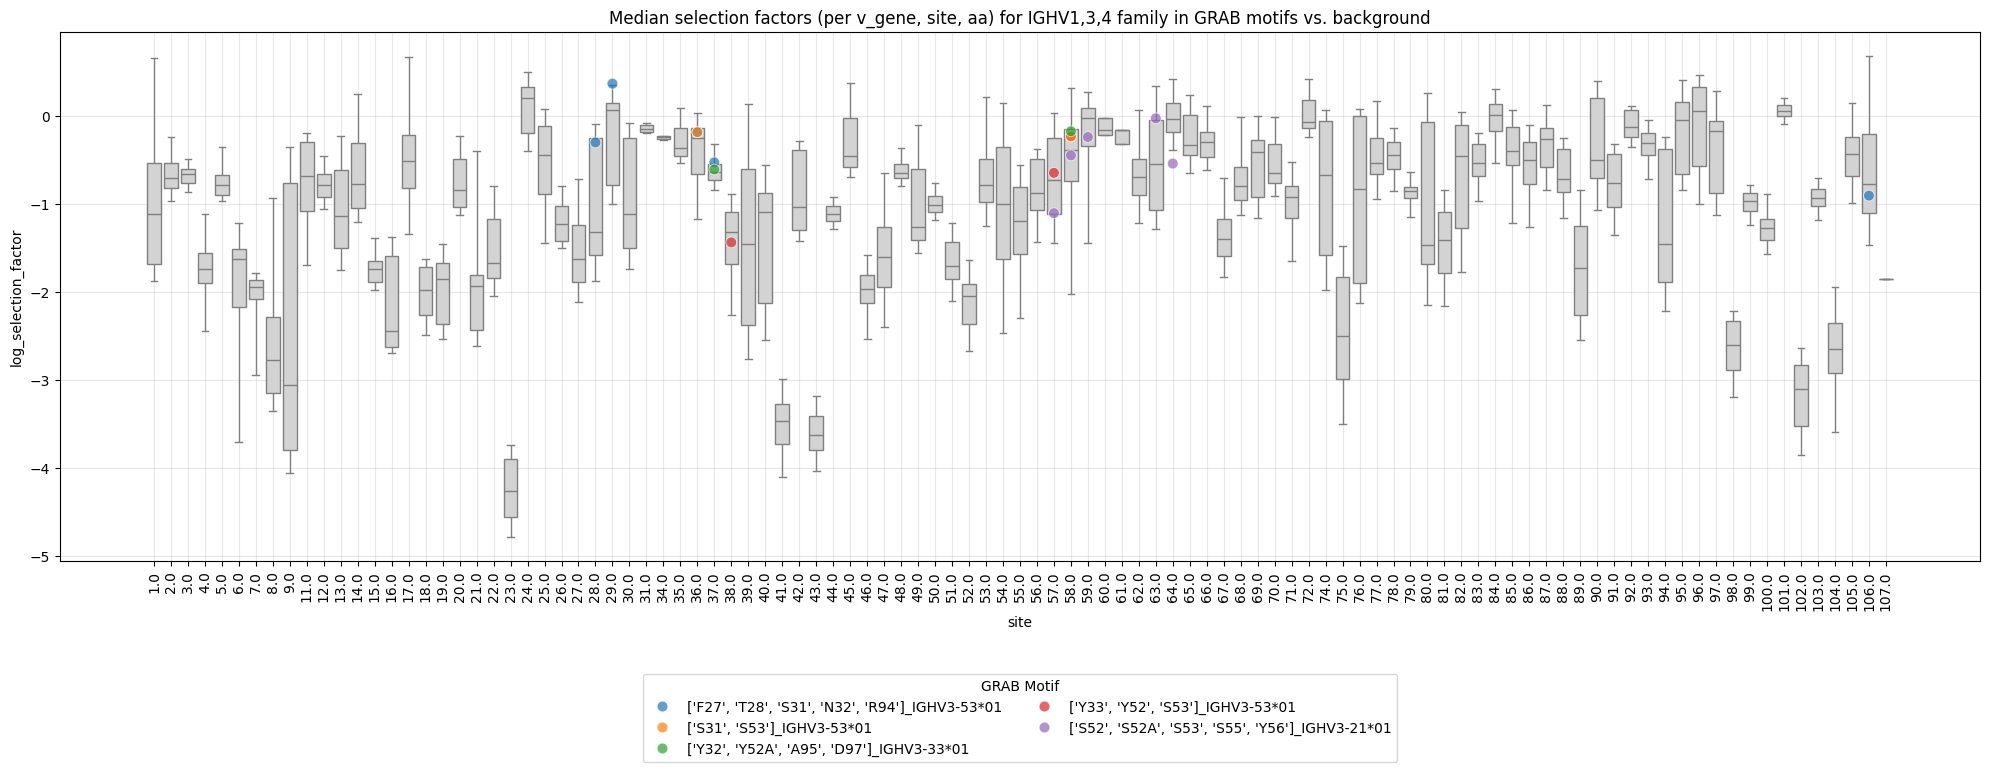

In [36]:
# Filter for IGHV1,3,4 family
ighv3_data = grab_motifs[grab_motifs.v_family.isin(['IGHV3', 'IGHV1', 'IGHV4'])].copy()

ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] = \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] + '_' + \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'v_gene']

# Convert site to string to ensure categorical treatment
ighv3_data['site'] = ighv3_data['site'].astype(str)

# Separate data into background (null motif) and GRAB motif
grab_data = ighv3_data[ighv3_data.Antibody_GRAB_motif_full.notnull()]

# Create the plot
fig, ax = plt.subplots(figsize=(20, 8))

# Plot boxplot for all data (background distribution per site)
sns.boxplot(data=ighv3_data, x='site', y='log_selection_factor', 
            color='lightgrey', ax=ax, showfliers=False, whis=[5, 95])

# Overlay GRAB motif data as colored scatter points
sns.scatterplot(data=grab_data, x='site', y='log_selection_factor', 
                hue='Antibody_GRAB_motif_full', ax=ax, s=60, zorder=10, palette='tab10', alpha=0.7)

# put the legend below the plot
ax.legend(title='GRAB Motif', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=2)
ax.set_title('Median selection factors (per v_gene, site, aa) for IGHV1,3,4 family in GRAB motifs vs. background')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_302560/2158564206.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


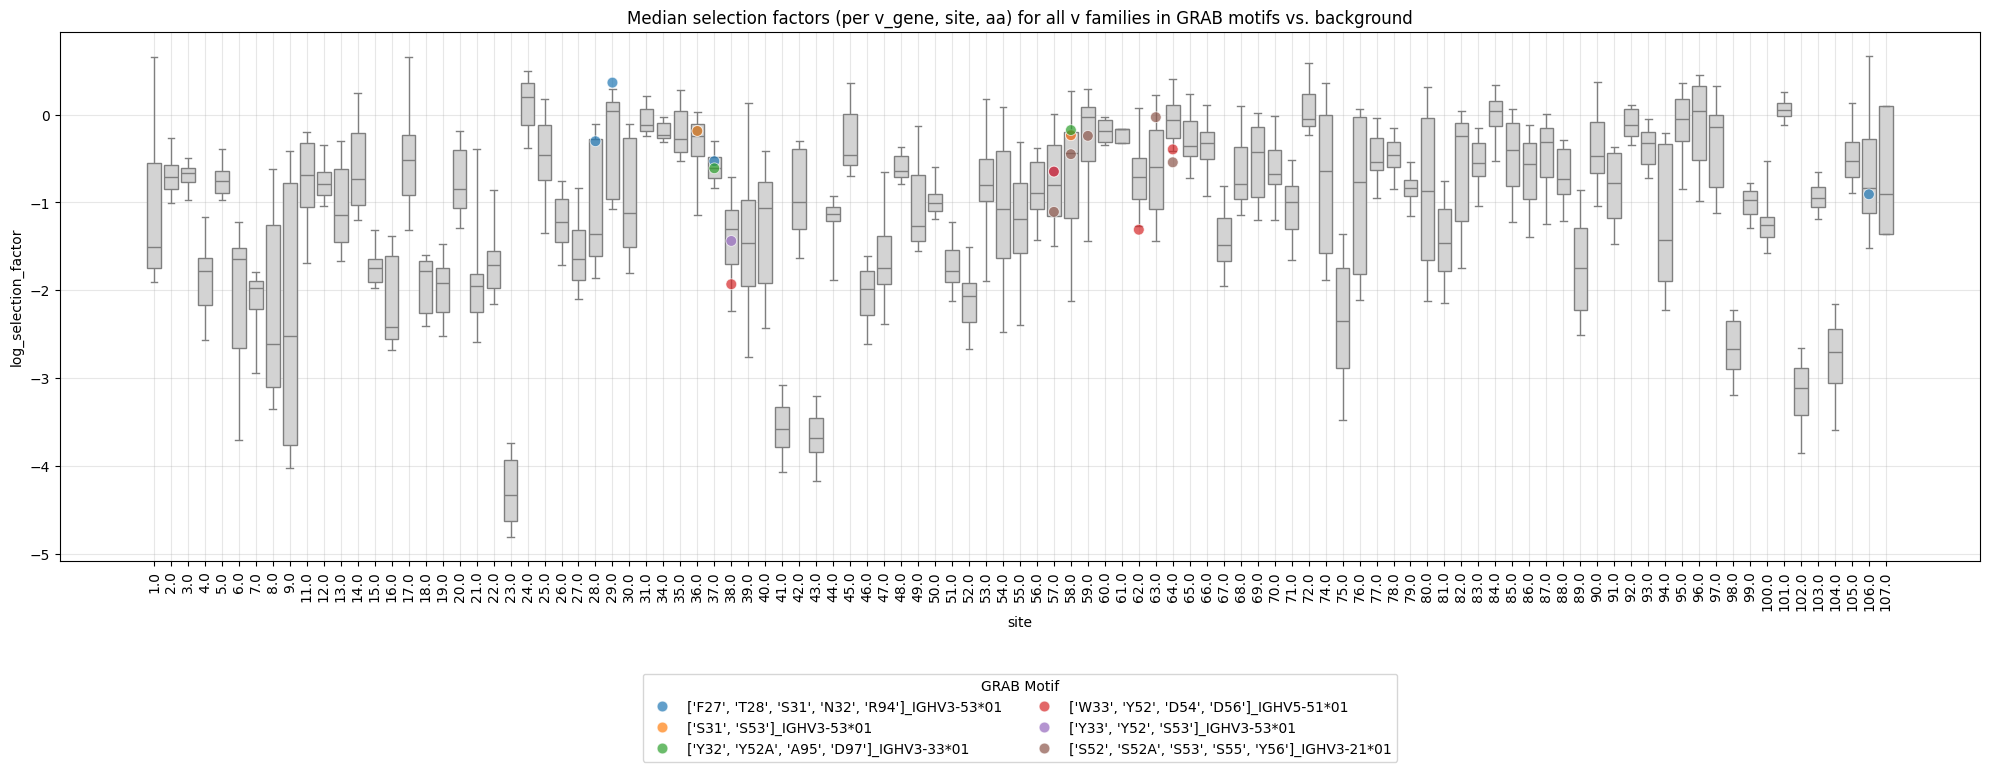

In [37]:
# all v families
ighv3_data = grab_motifs.copy()

ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] = \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] + '_' + \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'v_gene']

# Convert site to string to ensure categorical treatment
ighv3_data['site'] = ighv3_data['site'].astype(str)

# Separate data into background (null motif) and GRAB motif
grab_data = ighv3_data[ighv3_data.Antibody_GRAB_motif_full.notnull()]

# Create the plot
fig, ax = plt.subplots(figsize=(20, 8))

# Plot boxplot for all data (background distribution per site)
sns.boxplot(data=ighv3_data, x='site', y='log_selection_factor', 
            color='lightgrey', ax=ax, showfliers=False, whis=[5, 95])

# Overlay GRAB motif data as colored scatter points
sns.scatterplot(data=grab_data, x='site', y='log_selection_factor', 
                hue='Antibody_GRAB_motif_full', ax=ax, s=60, zorder=10, palette='tab10', alpha=0.7)

# put the legend below the plot
ax.legend(title='GRAB Motif', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=2)
ax.set_title('Median selection factors (per v_gene, site, aa) for all v families in GRAB motifs vs. background')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
ighv3_data.sort_values('Antibody_GRAB_motif_full')

,site,is_cdr,parent_aa,v_gene,v_family,log_selection_factor,Antibody_GRAB_motif_full
1713,28.0,True,F,IGHV3-53*01,IGHV3,-0.303665,"['F27', 'T28', 'S31', 'N32', 'R94']_IGHV3-53*01"
2050,37.0,True,N,IGHV3-53*01,IGHV3,-0.530229,"['F27', 'T28', 'S31', 'N32', 'R94']_IGHV3-53*01"
6358,106.0,True,R,IGHV3-53*01,IGHV3,-0.907035,"['F27', 'T28', 'S31', 'N32', 'R94']_IGHV3-53*01"
1809,29.0,True,T,IGHV3-53*01,IGHV3,0.363490,"['F27', 'T28', 'S31', 'N32', 'R94']_IGHV3-53*01"
2021,36.0,True,S,IGHV3-53*01,IGHV3,-0.186728,"['F27', 'T28', 'S31', 'N32', 'R94']_IGHV3-53*01"
...,...,...,...,...,...,...,...
6389,107.0,True,D,IGHV3-9*01,IGHV3,-1.855440,NaN
6390,107.0,True,I,IGHV2-70*15,IGHV2,0.184662,NaN
6391,107.0,True,I,IGHV2-70D*04,IGHV2,0.101116,NaN
6392,107.0,True,R,IGHV2-5*01,IGHV2,-1.360962,NaN


### V gene level analysis - depth = 2 - only slight changes, does not change the conclusions that most GRAB motifs are not under more purifying selection compared to other v genes


In [10]:
grab_motifs_from_paper = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/grab_motifs/grab_motifs_human_ighv_chothia_to_imgt_mapping.csv')


# Count occurrences of each v_gene
v_gene_counts = site_sub_probs_df[site_sub_probs_df.is_germline_codon == True][['v_gene', 'pcp_index']].drop_duplicates().v_gene.value_counts()
frequent_v_genes = v_gene_counts[v_gene_counts > 50].index

# Filter for frequent v_genes and then calculate median
median_log_selection_factors = site_sub_probs_df[
    (site_sub_probs_df.is_germline_codon == True) & 
    (site_sub_probs_df.depth == 2) &
    (site_sub_probs_df.v_gene.isin(frequent_v_genes))
].groupby(['site', 'is_cdr', 'parent_aa', 'v_gene', 'v_family']).log_selection_factor.median().reset_index().copy()



grab_motifs = pd.merge(median_log_selection_factors, grab_motifs_from_paper[['v_gene', 'amino_acid', 'imgt_position', 'Antibody_GRAB_motif_full']].rename(columns={'amino_acid': 'parent_aa', 'imgt_position': 'site'}), on=['v_gene', 'parent_aa', 'site'], how='left')


/tmp/ipykernel_482968/2158564206.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


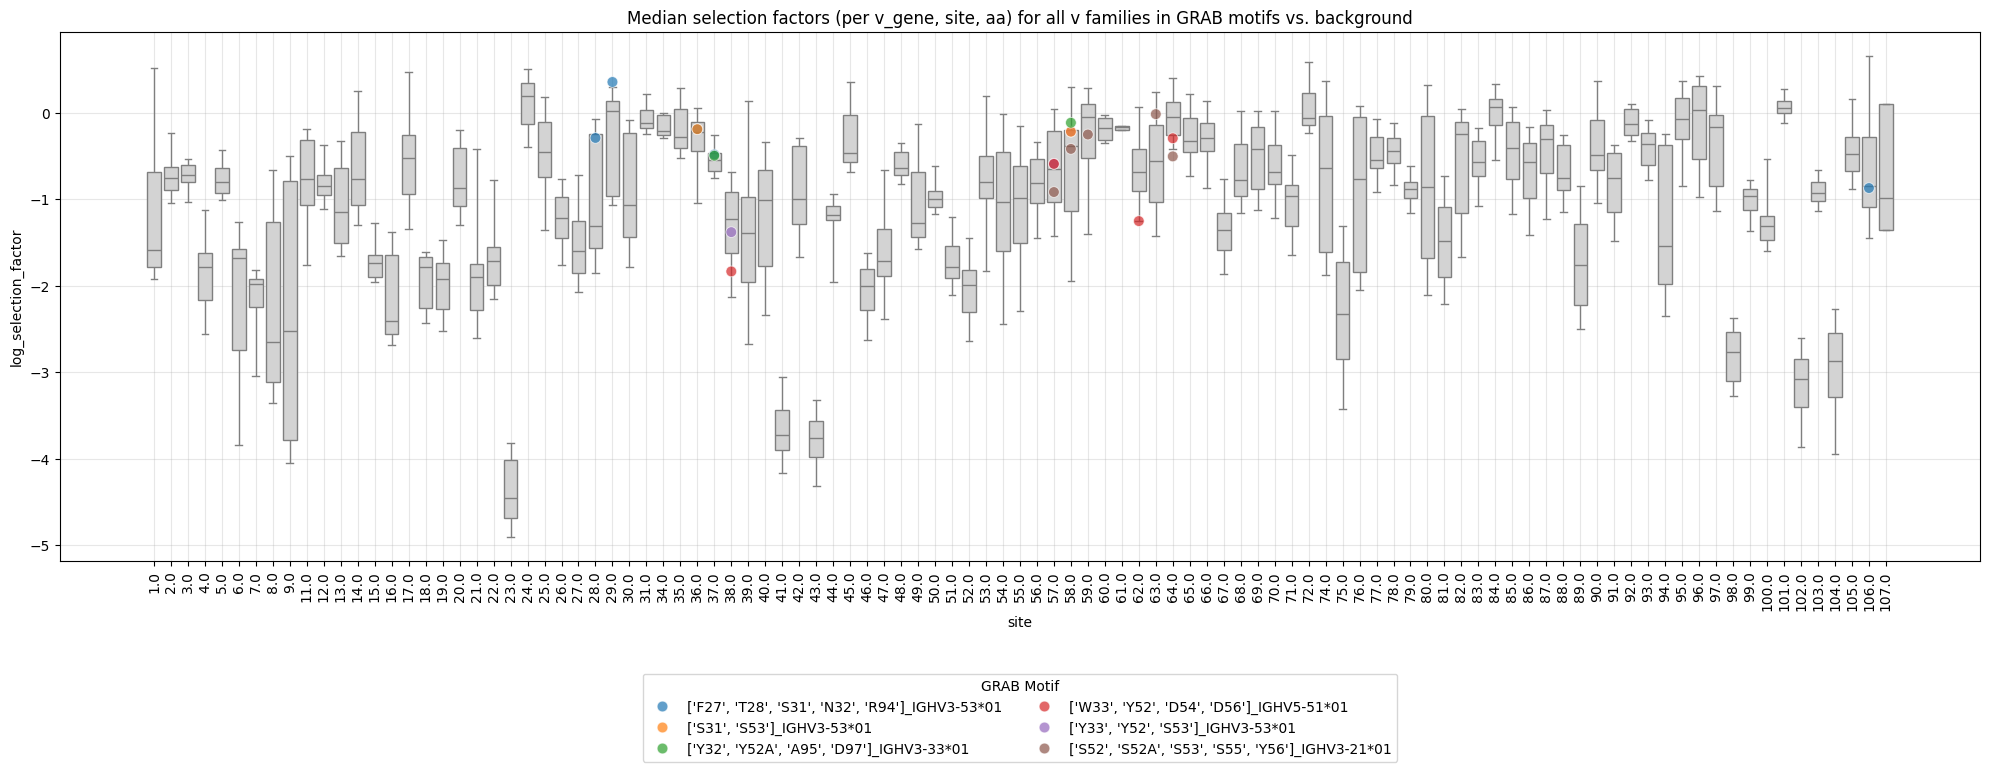

In [11]:
# all v families
ighv3_data = grab_motifs.copy()

ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] = \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] + '_' + \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'v_gene']

# Convert site to string to ensure categorical treatment
ighv3_data['site'] = ighv3_data['site'].astype(str)

# Separate data into background (null motif) and GRAB motif
grab_data = ighv3_data[ighv3_data.Antibody_GRAB_motif_full.notnull()]

# Create the plot
fig, ax = plt.subplots(figsize=(20, 8))

# Plot boxplot for all data (background distribution per site)
sns.boxplot(data=ighv3_data, x='site', y='log_selection_factor', 
            color='lightgrey', ax=ax, showfliers=False, whis=[5, 95])

# Overlay GRAB motif data as colored scatter points
sns.scatterplot(data=grab_data, x='site', y='log_selection_factor', 
                hue='Antibody_GRAB_motif_full', ax=ax, s=60, zorder=10, palette='tab10', alpha=0.7)

# put the legend below the plot
ax.legend(title='GRAB Motif', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=2)
ax.set_title('Median selection factors (per v_gene, site, aa) for all v families in GRAB motifs vs. background')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### V family level analysis

In [24]:
grab_motifs_from_paper.sort_values('imgt_position')

,v_gene,Antigen_Residue,Antibody_GRAB_motif,Examples,Antibody_GRAB_motif_full,chotia_site,amino_acid,chotia_site_numeric,v_family,imgt_position,confidence,germline_amino_acid
30,IGHV3-66*01,A475,F27,3 of 8 unique PDB Ab-Ag structures involving I...,"['F27', 'T28', 'S31', 'N32', 'R94']",27,F,27.0,IGHV3,28.0,100.0,F
23,IGHV3-53*01,A475,F27,22 of 24 unique PDB Ab-Ag structures involving...,"['F27', 'T28', 'S31', 'N32', 'R94']",27,F,27.0,IGHV3,28.0,100.0,F
31,IGHV3-66*01,A475,T28,3 of 8 unique PDB Ab-Ag structures involving I...,"['F27', 'T28', 'S31', 'N32', 'R94']",28,T,28.0,IGHV3,29.0,100.0,T
24,IGHV3-53*01,A475,T28,22 of 24 unique PDB Ab-Ag structures involving...,"['F27', 'T28', 'S31', 'N32', 'R94']",28,T,28.0,IGHV3,29.0,100.0,T
28,IGHV3-53*01,Y473,S31,NaN,"['S31', 'S53']",31,S,31.0,IGHV3,36.0,100.0,S
25,IGHV3-53*01,A475,S31,22 of 24 unique PDB Ab-Ag structures involving...,"['F27', 'T28', 'S31', 'N32', 'R94']",31,S,31.0,IGHV3,36.0,100.0,S
35,IGHV3-66*01,Y473,S31,NaN,"['S31', 'S53']",31,S,31.0,IGHV3,36.0,100.0,S
32,IGHV3-66*01,A475,S31,3 of 8 unique PDB Ab-Ag structures involving I...,"['F27', 'T28', 'S31', 'N32', 'R94']",31,S,31.0,IGHV3,36.0,100.0,S
37,IGHV3-33*01,N9,Y32,5 of 19 unique PDB Ab-Ag structures involving ...,"['Y32', 'Y52A', 'A95', 'D97']",32,Y,32.0,IGHV3,37.0,100.0,Y
33,IGHV3-66*01,A475,N32,3 of 8 unique PDB Ab-Ag structures involving I...,"['F27', 'T28', 'S31', 'N32', 'R94']",32,N,32.0,IGHV3,37.0,100.0,N


In [39]:
grab_motifs_from_paper = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/grab_motifs/grab_motifs_human_ighv_chothia_to_imgt_mapping.csv')


# Count occurrences of each v_gene
v_gene_counts = site_sub_probs_df[site_sub_probs_df.is_germline_codon == True][['v_gene', 'pcp_index']].drop_duplicates().v_gene.value_counts()
frequent_v_genes = v_gene_counts[v_gene_counts > 100].index

# Filter for frequent v_genes and then calculate median
median_log_selection_factors = site_sub_probs_df[
    (site_sub_probs_df.is_germline_codon == True) & 
    (site_sub_probs_df.v_gene.isin(frequent_v_genes))
].groupby(['site', 'is_cdr', 'parent_aa', 'v_family']).log_selection_factor.median().reset_index().copy()



grab_motifs = pd.merge(median_log_selection_factors, grab_motifs_from_paper[['v_family', 'amino_acid', 'imgt_position', 'Antibody_GRAB_motif_full']].rename(columns={'amino_acid': 'parent_aa', 'imgt_position': 'site'}), on=['v_family', 'parent_aa', 'site'], how='left')
grab_motifs

,site,is_cdr,parent_aa,v_family,log_selection_factor,Antibody_GRAB_motif_full
0,1.0,False,E,IGHV3,-0.717830,NaN
1,1.0,False,E,IGHV5,-0.860408,NaN
2,1.0,False,Q,IGHV1,-1.625508,NaN
3,1.0,False,Q,IGHV2,-2.384735,NaN
4,1.0,False,Q,IGHV3,0.647376,NaN
...,...,...,...,...,...,...
913,106.0,True,T,IGHV1,-0.580921,NaN
914,106.0,True,T,IGHV3,-0.828474,NaN
915,107.0,True,D,IGHV3,-1.855440,NaN
916,107.0,True,I,IGHV2,0.175149,NaN


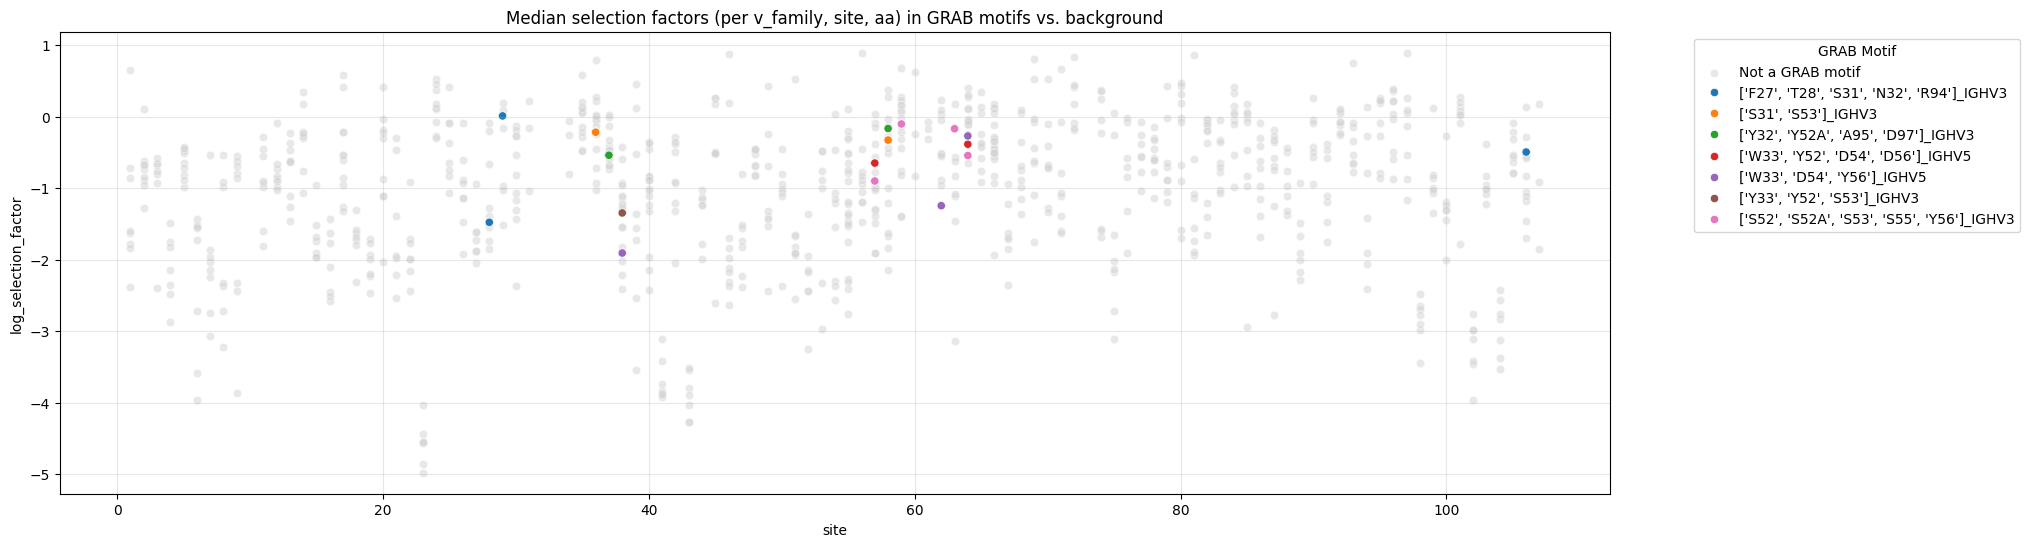

In [40]:
# Filter for IGHV3 family
ighv_data = grab_motifs.copy()
ighv_data['Antibody_GRAB_motif_full'] = ighv_data['Antibody_GRAB_motif_full'] + '_' + ighv_data['v_family']

# Separate data into background (null motif) and GRAB motif
background_data = ighv_data[ighv_data.Antibody_GRAB_motif_full.isnull()]
grab_data = ighv_data[ighv_data.Antibody_GRAB_motif_full.notnull()]

# Create the plot
fig, ax = plt.subplots(figsize=(20, 6))

# Plot background data in grey first (so it appears behind)
sns.scatterplot(data=background_data, x='site', y='log_selection_factor', 
                color='lightgrey', alpha=0.5, label='Not a GRAB motif', ax=ax)

# Plot GRAB motif data with color coding
sns.scatterplot(data=grab_data, x='site', y='log_selection_factor', 
                hue='Antibody_GRAB_motif_full', ax=ax)

ax.legend(title='GRAB Motif', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Median selection factors (per v_family, site, aa) in GRAB motifs vs. background')
ax.grid(True, alpha=0.3)

plt.show()

/tmp/ipykernel_302560/2757863692.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


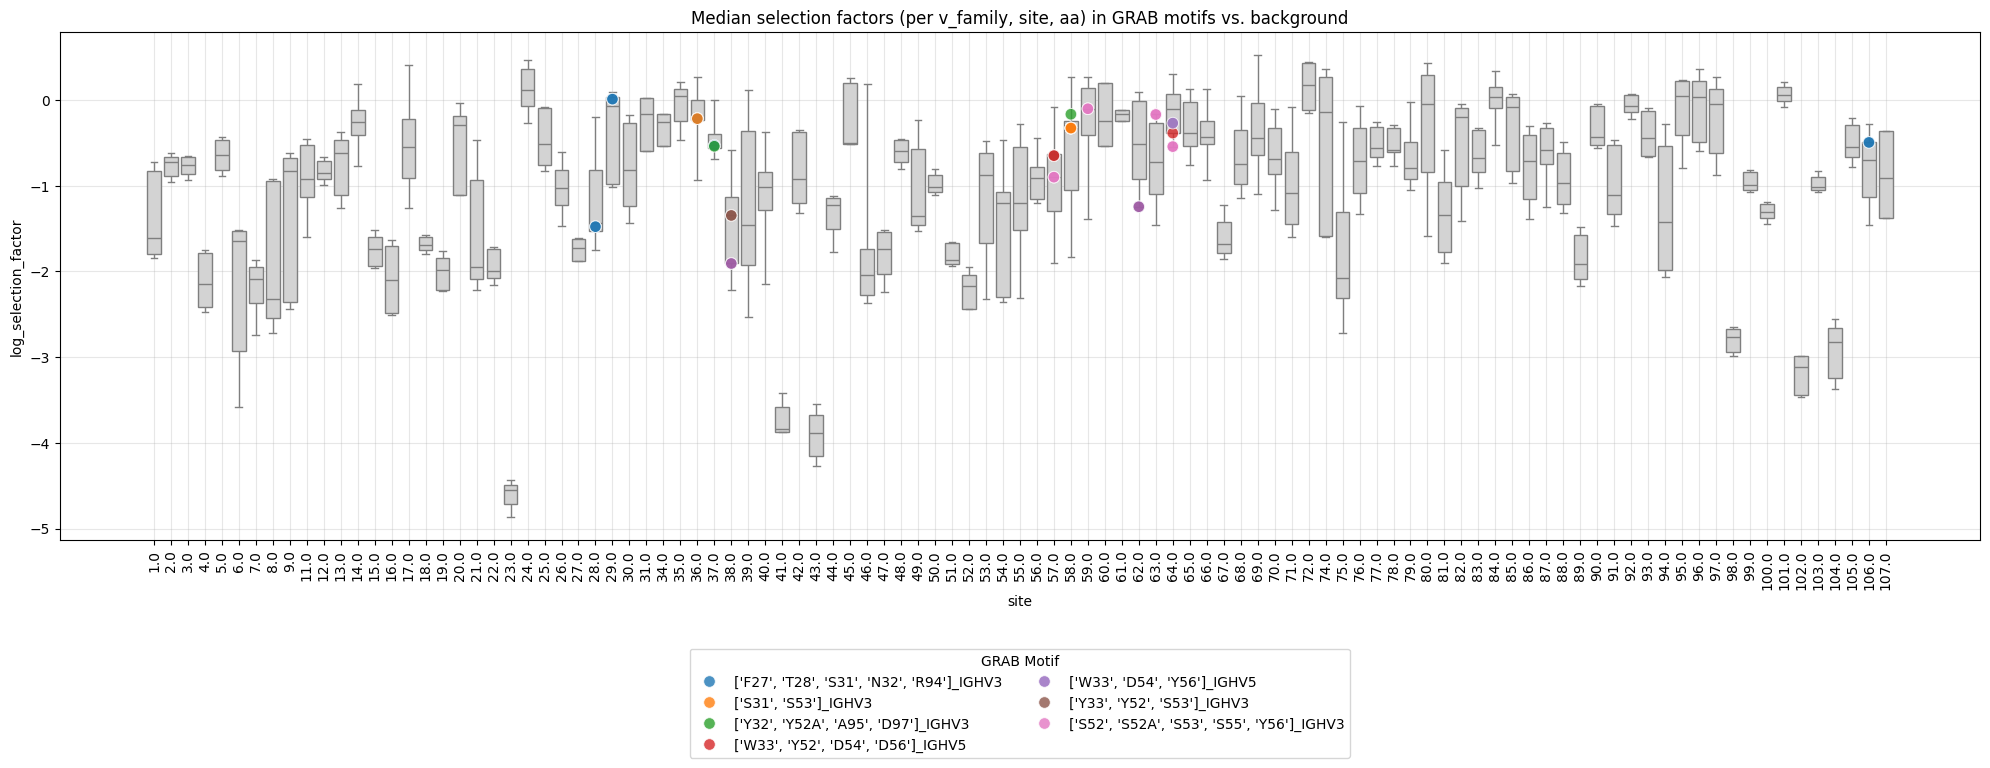

In [41]:
# Filter for IGHV3 family
ighv_data = grab_motifs.copy()
ighv_data.loc[ighv_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] = \
    ighv_data.loc[ighv_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] + '_' + \
    ighv_data.loc[ighv_data.Antibody_GRAB_motif_full.notnull(), 'v_family']

# Convert site to string to ensure categorical treatment
ighv_data['site'] = ighv_data['site'].astype(str)

# Separate data into background (null motif) and GRAB motif
grab_data = ighv_data[ighv_data.Antibody_GRAB_motif_full.notnull()]

# Create the plot
fig, ax = plt.subplots(figsize=(20, 8))

# Plot boxplot for all data (background distribution per site)
sns.boxplot(data=ighv_data, x='site', y='log_selection_factor', 
            color='lightgrey', ax=ax, showfliers=False, whis=[5, 95])

# Overlay GRAB motif data as colored scatter points
sns.scatterplot(data=grab_data, x='site', y='log_selection_factor', 
                hue='Antibody_GRAB_motif_full', ax=ax, s=70, zorder=10, palette='tab10', alpha=0.8)

# put the legend below the plot
ax.legend(title='GRAB Motif', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=2)
ax.set_title('Median selection factors (per v_family, site, aa) in GRAB motifs vs. background')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
ighv_data.sort_values('Antibody_GRAB_motif_full')

NameError: name 'ighv_data' is not defined